## Evaluation of Outlier Detection Algorithms for Epileptic Seizure Recognition Dataset

### 1. Preparation

#### 1.1. Dataset

This dataset is a preprocessed and restructured version of the Bonn EEG data. It contains 11500 rows with each row having 180 columns. The first column (Unnamed) represents patient ID and it's not used while the last column (y) is the class label each row belongs The dataset was previously available on UCI repository, but for some unknown reason, it's no longer available on the page. The data can be downloaded from <a href="https://www.kaggle.com/datasets/harunshimanto/epileptic-seizure-recognition/data">kaggle</a>. <br/> The variable y in the dataset has the following five possible classes:
- 5 - Eyes open, which means that when they were recording the EEG signal, the patients had their eyes opened.
- 4 - Eyes closed, which means that when they were recording the EEG signal, the patients had their eyes closed.
- 3 - Yes, they identified where the region of the tumor was in the brain and recorded the EEG activity from the healthy brain area.
- 2 - They recorded the EEG signal from the area where the tumor was located.
- 1 - EEG recording of seizure activity.

<br/>An epileptic seizure was not recorded in classes 2, 3, 4, and 5. Only class 1 had epileptic seizure recording. 

The performance of the following outlier detection algorithms will be evaluated on the dataset
1. Local Outlier Factor
2. Isolation Forest
3. One Class Support Vector Machine
4. Minimum Covariance Determinant
5. Density-Based Spatial Clustering of Applications with Noise (DBSCAN)

#### 1.2. Import Libraries

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from IPython.display import display, HTML
from datetime import datetime
from sklearn.preprocessing import RobustScaler, MinMaxScaler, Normalizer, StandardScaler, SplineTransformer
from sklearn.metrics import RocCurveDisplay, accuracy_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope 
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, roc_curve, auc, balanced_accuracy_score
from sklearn.model_selection import ParameterGrid

Fontconfig warning: ignoring UTF-8: not a valid region tag
Matplotlib is building the font cache; this may take a moment.


In [11]:
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.options.display.max_colwidth = None
pd.set_option("display.float_format", lambda x: '%.2f' % x)

# Plot style
plt.style.use('ggplot')
display(HTML("<style>.container { width:100% !important; }</style>"))

#### 1.3. Inspect and Visualize Dataset

In [12]:
# Read data from file
epileptic_seizure_data = pd.read_csv('Epileptic Seizure Recognition.csv')

In [13]:
# Reset pandas to avoid scrolling through the columns
pd.reset_option('max_columns')
epileptic_seizure_data.head()

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [14]:
# Drop the Unnamed column
epileptic_seizure_data = epileptic_seizure_data.drop(['Unnamed'], axis=1)

In [15]:
epileptic_seizure_data.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,135,190,229,223,192,125,55,-9,-33,-38,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,386,382,356,331,320,315,307,272,244,232,...,164,150,146,152,157,156,154,143,129,1
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [16]:
epileptic_seizure_data.tail()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
11495,-22,-22,-23,-26,-36,-42,-45,-42,-45,-49,...,15,16,12,5,-1,-18,-37,-47,-48,2
11496,-47,-11,28,77,141,211,246,240,193,136,...,-65,-33,-7,14,27,48,77,117,170,1
11497,14,6,-13,-16,10,26,27,-9,4,14,...,-65,-48,-61,-62,-67,-30,-2,-1,-8,5
11498,-40,-25,-9,-12,-2,12,7,19,22,29,...,121,135,148,143,116,86,68,59,55,3
11499,29,41,57,72,74,62,54,43,31,23,...,-59,-25,-4,2,5,4,-2,2,20,4


In [17]:
# Check data types and missing values
epileptic_seizure_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Columns: 179 entries, X1 to y
dtypes: int64(179)
memory usage: 15.7 MB


In [18]:
# Get the distinct classes
distinct_classes = epileptic_seizure_data['y'].unique()
distinct_classes

array([4, 1, 5, 2, 3])

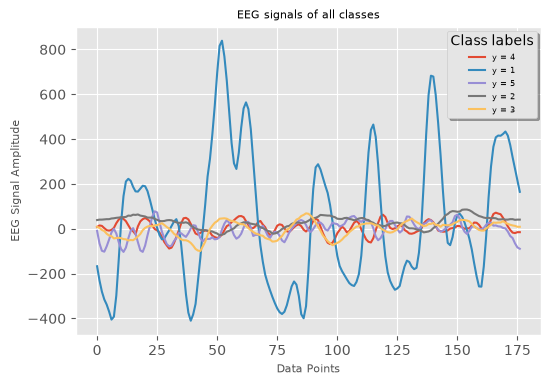

In [19]:
# Plot of all the classes on one plot
plt.figure(figsize=(6, 4))
# Iterate over the classes and plot the sample data
for label in distinct_classes:
    class_data = epileptic_seizure_data[epileptic_seizure_data['y'] == label]
    sample_index = 2
    sample_data = class_data.iloc[sample_index]
    plt.plot(sample_data.values[:-2], label=f'y = {label}')

# Set the plot title and labels
plt.title('EEG signals of all classes', fontsize=8)
plt.xlabel('Data Points', fontsize=8)
plt.ylabel('EEG Signal Amplitude', fontsize=8)
plt.legend(title='Class labels', shadow=True, fontsize=6)
#plt.grid(True)

# Show the plot
plt.show()

In [11]:
# Replace the non-eplileptic seizure classes with 0 and leave the seizure class as 1
# Now, we have just 2 distinct classes
# y=0 represents no seizure, y=1 represents seizure
epileptic_seizure_data = epileptic_seizure_data.replace([2, 3, 4, 5], [0, 0, 0 ,0])

In [12]:
epileptic_seizure_data.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,135,190,229,223,192,125,55,-9,-33,-38,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,0
1,386,382,356,331,320,315,307,272,244,232,...,164,150,146,152,157,156,154,143,129,1
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,57,64,48,19,-12,-30,-35,-35,-36,0
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,0
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,0,0,-12,-32,-41,-65,-83,-89,-73,0


In [13]:
epileptic_seizure_data.tail()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
11495,-22,-22,-23,-26,-36,-42,-45,-42,-45,-49,...,15,16,12,0,-1,-18,-37,-47,-48,0
11496,-47,-11,28,77,141,211,246,240,193,136,...,-65,-33,-7,14,27,48,77,117,170,1
11497,14,6,-13,-16,10,26,27,-9,0,14,...,-65,-48,-61,-62,-67,-30,-2,-1,-8,0
11498,-40,-25,-9,-12,-2,12,7,19,22,29,...,121,135,148,143,116,86,68,59,55,0
11499,29,41,57,72,74,62,54,43,31,23,...,-59,-25,-4,0,0,0,-2,0,20,0


In [14]:
# Get the 2 distinct classes
distinct_classes = epileptic_seizure_data['y'].unique()
distinct_classes

array([0, 1])

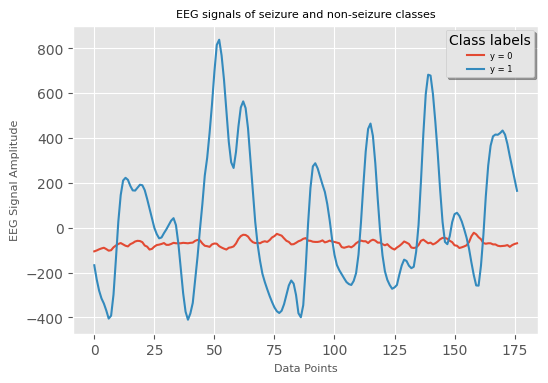

In [15]:
# Plot of 2 the classes on one plot
plt.figure(figsize=(6, 4))
# Iterate over the classes and plot the sample data
for label in distinct_classes:
    class_data = epileptic_seizure_data[epileptic_seizure_data['y'] == label]
    sample_index = 2
    sample_data = class_data.iloc[sample_index]
    plt.plot(sample_data.values[:-2], label=f'y = {label}')

# Set the plot title and labels
plt.title('EEG signals of seizure and non-seizure classes', fontsize=8)
plt.xlabel('Data Points', fontsize=8)
plt.ylabel('EEG Signal Amplitude', fontsize=8)
plt.legend(title='Class labels', shadow=True, fontsize=6)
#plt.grid(True)

# Show the plot
plt.show()

In [16]:
# Define class labels for the 2 distinct classes by defining a dict
class_labels = {
    
    0: 'Non-seizure',
    1: 'Seizure'
}
# Map the class labels and create a column for these labels
epileptic_seizure_data['y_class'] = epileptic_seizure_data['y'].map(class_labels)
epileptic_seizure_data.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X171,X172,X173,X174,X175,X176,X177,X178,y,y_class
0,135,190,229,223,192,125,55,-9,-33,-38,...,-15,-31,-77,-103,-127,-116,-83,-51,0,Non-seizure
1,386,382,356,331,320,315,307,272,244,232,...,150,146,152,157,156,154,143,129,1,Seizure
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,64,48,19,-12,-30,-35,-35,-36,0,Non-seizure
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-81,-80,-77,-85,-77,-72,-69,-65,0,Non-seizure
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,0,-12,-32,-41,-65,-83,-89,-73,0,Non-seizure


In [17]:
epileptic_seizure_data.tail()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X171,X172,X173,X174,X175,X176,X177,X178,y,y_class
11495,-22,-22,-23,-26,-36,-42,-45,-42,-45,-49,...,16,12,0,-1,-18,-37,-47,-48,0,Non-seizure
11496,-47,-11,28,77,141,211,246,240,193,136,...,-33,-7,14,27,48,77,117,170,1,Seizure
11497,14,6,-13,-16,10,26,27,-9,0,14,...,-48,-61,-62,-67,-30,-2,-1,-8,0,Non-seizure
11498,-40,-25,-9,-12,-2,12,7,19,22,29,...,135,148,143,116,86,68,59,55,0,Non-seizure
11499,29,41,57,72,74,62,54,43,31,23,...,-25,-4,0,0,0,-2,0,20,0,Non-seizure


In [18]:
two_distinct_classes = epileptic_seizure_data['y_class'].unique()
class_value_counts = epileptic_seizure_data['y'].value_counts()
print(two_distinct_classes)
print(class_value_counts)

['Non-seizure' 'Seizure']
y
0    9200
1    2300
Name: count, dtype: int64


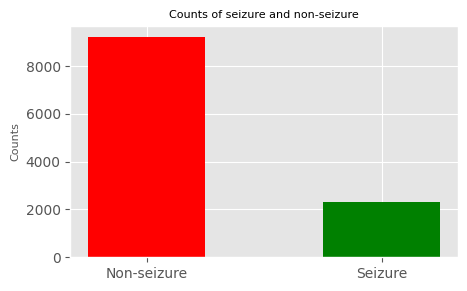

In [19]:
# Plot the counts of seizure and non-seizure data points in the dataset
plt.figure(figsize=(5, 3))
plt.bar(two_distinct_classes, class_value_counts, color=['red', 'green'], width=0.5)
plt.title('Counts of seizure and non-seizure', fontsize=8)
plt.ylabel('Counts', fontsize=8)
plt.show()

### 2. Outlier Detection 
In this section, the classical outlier detection algorithms will be used to identify the outlying data points in the dataset. These algorithms include the following:
- Local Outlier Factor (LOF)
- One Class Support Vector Machine (OneClassSVM)
- Isolation Forest (iForest)
- Minimum Covariance Determinant (MCD)

#### 2.1. Preliminaries

##### The following points should be noted concerning the dataset target y
1. y = 0 indicates non-seizure
2. y = 1 indicates seizure
3. We consider seizure as outliers and non-seizure as inliers: outliers = 1, inliers = 0

In [20]:
# Remove label columns
X = epileptic_seizure_data.drop(['y', 'y_class'], axis=1)

In [21]:
X.shape

(11500, 178)

In [22]:
X.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X169,X170,X171,X172,X173,X174,X175,X176,X177,X178
0,135,190,229,223,192,125,55,-9,-33,-38,...,8,-17,-15,-31,-77,-103,-127,-116,-83,-51
1,386,382,356,331,320,315,307,272,244,232,...,168,164,150,146,152,157,156,154,143,129
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,29,57,64,48,19,-12,-30,-35,-35,-36
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-80,-82,-81,-80,-77,-85,-77,-72,-69,-65
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,10,0,0,-12,-32,-41,-65,-83,-89,-73


In [23]:
# Convert X to numpy array
X = X.to_numpy()

In [24]:
X.shape

(11500, 178)

In [25]:
X[:10]

array([[ 135,  190,  229, ..., -116,  -83,  -51],
       [ 386,  382,  356, ...,  154,  143,  129],
       [ -32,  -39,  -47, ...,  -35,  -35,  -36],
       ...,
       [   1,   -2,   -8, ...,  -66,  -57,  -39],
       [-278, -246, -215, ..., -125,  -79,  -40],
       [   8,   15,   13, ...,  -15,  -15,  -11]], shape=(10, 178))

In [26]:
y_true = epileptic_seizure_data['y'].to_numpy()

In [27]:
y_true.shape

(11500,)

In [28]:
y_true[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

In [29]:
y = epileptic_seizure_data['y']

In [30]:
y.shape

(11500,)

In [31]:
# Print the number and percentage of outliers in the dataset
n_samples, outlier_frac = X.shape[0], y_true.mean()
print(f"{n_samples} datapoints with {y_true.sum()} outliers ({outlier_frac:.02%})")

11500 datapoints with 2300 outliers (20.00%)


In [32]:
# Preprocessing methods
# None means no preprocessing
preprocessor_list = [
    None,
    StandardScaler(),
    RobustScaler(),
    MinMaxScaler(),
    Normalizer(),
    SplineTransformer()
]

#### 2.2. Explained Variance and PCA for 2-D Visualization

In [33]:
# Fit PCA with the data to return an object
X_pca = PCA(n_components=2).fit(X)

In [34]:
# Get the explained variance ratio of the principal components
X_pca.explained_variance_ratio_

array([0.05587782, 0.05256166])

- The first two principal components account for about 10.6% variability in the data. Thus, there are still a lot of variability in the remaining principal components in the dataset. 

In [35]:
# Actual variance in the data
X_pca.explained_variance_

array([269402.49574084, 253414.34614713])

In [36]:
# To visualize the data in 2-D space, transform the data using PCA
X_reduced = PCA(n_components=2).fit_transform(X)
# Convert the PCA data to a dataframe
X_reduced_df = pd.DataFrame(data=X_reduced, columns=['PC1', 'PC2'])

In [37]:
X_reduced_df.shape

(11500, 2)

In [38]:
X_reduced_df.head()

,PC1,PC2
0,-91.36,184.32
1,-313.08,474.98
2,91.34,41.91
3,-10.69,-48.28
4,-36.03,-16.85


In [39]:
y_true

array([0, 1, 0, ..., 0, 0, 0], shape=(11500,))

In [40]:
# Include the target in the dataframe
X_reduced_df['y'] = y
X_reduced_df['outlier'] = y.replace([1, 0], ["Yes", "No"])

In [41]:
X_reduced_df.head()

,PC1,PC2,y,outlier
0,-91.36,184.32,0,No
1,-313.08,474.98,1,Yes
2,91.34,41.91,0,No
3,-10.69,-48.28,0,No
4,-36.03,-16.85,0,No


In [42]:
X_reduced_df.tail()

,PC1,PC2,y,outlier
11495,-2.73,52.10,0,No
11496,-46.00,694.31,1,Yes
11497,-52.37,21.52,0,No
11498,-45.54,176.59,0,No
11499,20.53,-48.80,0,No


In [43]:
# Function for 2-D scatter plot of the data
def outlier_scatter_plot(X_reduced_df, outlier_column, model_name=None):
    plt.figure(figsize=(6, 4))

    plt.scatter(X_reduced_df[X_reduced_df[outlier_column]=="No"]['PC1'], 
                    X_reduced_df[X_reduced_df[outlier_column]=="No"]['PC2'], 
                    c='black',
                    s=5*2,
                    label='Non-seizure: Inliers')
    
    plt.scatter(X_reduced_df[X_reduced_df[outlier_column]=="Yes"]['PC1'], 
                    X_reduced_df[X_reduced_df[outlier_column]=="Yes"]['PC2'], 
                    c='red',
                    s=5*2,
                    label='Seizure: Outliers')

    if model_name is None:
        plt.title("Epileptic seizure dataset (inliers vs outliers)", fontsize=8)

    else:
        plt.title(f"{model_name} (inliers vs outliers)", fontsize=8)
    plt.legend(shadow=True, fontsize=6)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel("PC1", fontsize=8)
    plt.ylabel("PC2", fontsize=8)

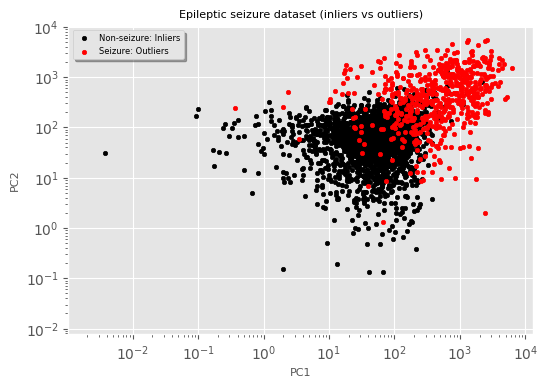

In [44]:
outlier_scatter_plot(X_reduced_df, 'outlier')

#### 2.3. Hyperparameter Tuning

The hyperparameters of the outlier detection models need to be tuned to identify and select the optimal hyperparameters that will be used in training the models. At the same time, the following scaling methods are combined with these hyperparameters to identify the optimal scaling methods for the data.
- StandardScaler
- RobustScaler
- MinMaxScaler
- SplineTransformer
- Normalizer
  
<b> The following two points should be noted in all of the ROC curve plots

- The inliers (class label 1) belongs to the negative class
- The outliers (class label 0) belongs to the positive class

#### 2.3.1. Local Outlier Factor

In [54]:
# LOF parameters and parameter grid
n_neighbors_values = (n_samples * np.array([0.05, 0.005, 0.04, 0.03, 0.02, 0.01])).astype(np.int32)
# n_neighbors_values = (n_samples * np.array([0.05, 0.005, 0.04, 0.004, 0.03, 0.02, 0.01])).astype(np.int32)
# 0.00.0045, 0.004, 0.0035, 0.003, 0.0028, 0.0025, 0.001]
p_values = [1, 2]
lof_params = {'scaler': preprocessor_list, 'n_neighbors': n_neighbors_values, 'p': p_values}

# Define parameter grid
lof_param_grid = ParameterGrid(lof_params)

In [55]:
# 575, 57, 460, 46, 345, 230, 115

In [56]:
len(lof_param_grid)

72

In [ ]:
#(n_samples * np.array([0.05, 0.005, 0.04, 0.004, 0.03, 0.003, 0.02, 0.01, 0.001])).astype(np.int32)

array([575,  57, 460,  46, 345,  34, 230, 115,  11])

In [57]:
list(lof_param_grid)[:10]

[{'n_neighbors': np.int32(575), 'p': 1, 'scaler': None},
 {'n_neighbors': np.int32(575), 'p': 1, 'scaler': StandardScaler()},
 {'n_neighbors': np.int32(575), 'p': 1, 'scaler': RobustScaler()},
 {'n_neighbors': np.int32(575), 'p': 1, 'scaler': MinMaxScaler()},
 {'n_neighbors': np.int32(575), 'p': 1, 'scaler': Normalizer()},
 {'n_neighbors': np.int32(575), 'p': 1, 'scaler': SplineTransformer()},
 {'n_neighbors': np.int32(575), 'p': 2, 'scaler': None},
 {'n_neighbors': np.int32(575), 'p': 2, 'scaler': StandardScaler()},
 {'n_neighbors': np.int32(575), 'p': 2, 'scaler': RobustScaler()},
 {'n_neighbors': np.int32(575), 'p': 2, 'scaler': MinMaxScaler()}]

In [58]:
lof_best_rocauc_score = -1
lof_best_params = {}
lof_params_metric_scores = []

# Start time 
start_time = datetime.now()

for params in lof_param_grid:
    scaler = params['scaler']
    n_neighbors = params['n_neighbors']
    p = params['p']
    
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, p=p, contamination=outlier_frac, n_jobs=-1)

    if scaler is None:
        model = make_pipeline(lof)
    else:
        model = make_pipeline(scaler, lof)
        
    model.fit(X)
    y_scores = model[-1].negative_outlier_factor_
    fpr, tpr, thresholds = roc_curve(y_true, y_scores, pos_label=0)
    auc_score = auc(fpr, tpr)
    # Add new key-value pair using dictionary unpacking
    lof_params_metric_scores.append({**params, 'auc_score': auc_score})
    
    if auc_score > lof_best_rocauc_score:
        lof_best_rocauc_score = auc_score
        lof_best_params = params

# End time 
end_time = datetime.now()
runtime_duration = end_time - start_time
print(f"Runtime: {runtime_duration.total_seconds()} seconds")
print(f"LOF best rocauc score: {lof_best_rocauc_score}")
print(f"LOF best parameters: {lof_best_params}")

Runtime: 452.442294 seconds
LOF best rocauc score: 0.9924901228733458
LOF best parameters: {'n_neighbors': np.int32(230), 'p': 2, 'scaler': StandardScaler()}


In [59]:
# Sort in descending order according to roc-auc score
lof_params_metric_scores.sort(key=lambda x: x['auc_score'], reverse=True)

In [60]:
lof_params_metric_scores[:10]

[{'n_neighbors': np.int32(230),
  'p': 2,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.9924901228733458)},
 {'n_neighbors': np.int32(230),
  'p': 2,
  'scaler': None,
  'auc_score': np.float64(0.9924723062381853)},
 {'n_neighbors': np.int32(230),
  'p': 2,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.9924692344045368)},
 {'n_neighbors': np.int32(230),
  'p': 2,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.9924659262759925)},
 {'n_neighbors': np.int32(345),
  'p': 2,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.9921227788279772)},
 {'n_neighbors': np.int32(345),
  'p': 2,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.9921103969754255)},
 {'n_neighbors': np.int32(345),
  'p': 2,
  'scaler': None,
  'auc_score': np.float64(0.9921099243856332)},
 {'n_neighbors': np.int32(345),
  'p': 2,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.992101843100189)},
 {'n_neighbors': np.int32(230),
  'p': 2,
  'scaler': SplineTransformer()

In [61]:
len(lof_params_metric_scores)

72

In [62]:
# Get the best hyperparater values for SplineTransformer
lof_spline_params_metric_scores = [s for s in lof_params_metric_scores if str(s['scaler']) == 'SplineTransformer()']

In [63]:
lof_spline_params_metric_scores[:5]

[{'n_neighbors': np.int32(230),
  'p': 2,
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.9920910680529301)},
 {'n_neighbors': np.int32(345),
  'p': 2,
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.9920275992438563)},
 {'n_neighbors': np.int32(460),
  'p': 2,
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.9918186200378071)},
 {'n_neighbors': np.int32(345),
  'p': 1,
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.99175179584121)},
 {'n_neighbors': np.int32(230),
  'p': 1,
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.991689933837429)}]

In [64]:
len(lof_spline_params_metric_scores)

12

In [65]:
# Get the best hyperparater values for None
lof_none_params_metric_scores = [s for s in lof_params_metric_scores if str(s['scaler']) == 'None']

In [66]:
lof_none_params_metric_scores[:5]

[{'n_neighbors': np.int32(230),
  'p': 2,
  'scaler': None,
  'auc_score': np.float64(0.9924723062381853)},
 {'n_neighbors': np.int32(345),
  'p': 2,
  'scaler': None,
  'auc_score': np.float64(0.9921099243856332)},
 {'n_neighbors': np.int32(115),
  'p': 2,
  'scaler': None,
  'auc_score': np.float64(0.9919831758034027)},
 {'n_neighbors': np.int32(230),
  'p': 1,
  'scaler': None,
  'auc_score': np.float64(0.9919581758034026)},
 {'n_neighbors': np.int32(345),
  'p': 1,
  'scaler': None,
  'auc_score': np.float64(0.991790595463138)}]

In [67]:
len(lof_none_params_metric_scores)

12

In [68]:
# Get the best hyperparater values for StandardScaler
lof_standard_params_metric_scores = [s for s in lof_params_metric_scores if str(s['scaler']) == 'StandardScaler()']

In [69]:
lof_standard_params_metric_scores[:5]

[{'n_neighbors': np.int32(230),
  'p': 2,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.9924901228733458)},
 {'n_neighbors': np.int32(345),
  'p': 2,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.9921103969754255)},
 {'n_neighbors': np.int32(115),
  'p': 2,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.9919883742911154)},
 {'n_neighbors': np.int32(230),
  'p': 1,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.9919647920604915)},
 {'n_neighbors': np.int32(345),
  'p': 1,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.9918051039697543)}]

In [70]:
len(lof_standard_params_metric_scores)

12

In [71]:
# Get the best hyperparater values for RobustScaler
lof_robust_params_metric_scores = [s for s in lof_params_metric_scores if str(s['scaler']) == 'RobustScaler()']

In [72]:
lof_robust_params_metric_scores[:5]

[{'n_neighbors': np.int32(230),
  'p': 2,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.9924692344045368)},
 {'n_neighbors': np.int32(345),
  'p': 2,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.992101843100189)},
 {'n_neighbors': np.int32(115),
  'p': 2,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.9920115311909263)},
 {'n_neighbors': np.int32(230),
  'p': 1,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.9919692816635161)},
 {'n_neighbors': np.int32(345),
  'p': 1,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.9917897920604916)}]

In [73]:
len(lof_robust_params_metric_scores)

12

In [74]:
# Get the best hyperparater values for MinMaxScaler
lof_minmax_params_metric_scores = [s for s in lof_params_metric_scores if str(s['scaler']) == 'MinMaxScaler()']

In [75]:
lof_minmax_params_metric_scores[:5]

[{'n_neighbors': np.int32(230),
  'p': 2,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.9924659262759925)},
 {'n_neighbors': np.int32(345),
  'p': 2,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.9921227788279772)},
 {'n_neighbors': np.int32(230),
  'p': 1,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.9920003308128545)},
 {'n_neighbors': np.int32(115),
  'p': 2,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.9919085538752362)},
 {'n_neighbors': np.int32(345),
  'p': 1,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.9918284499054821)}]

In [76]:
len(lof_minmax_params_metric_scores)

12

In [77]:
# Get the best hyperparater values for Normalizer
lof_normalizer_params_metric_scores = [s for s in lof_params_metric_scores if str(s['scaler']) == 'Normalizer()']

In [78]:
lof_normalizer_params_metric_scores[:5]

[{'n_neighbors': np.int32(575),
  'p': 1,
  'scaler': Normalizer(),
  'auc_score': np.float64(0.5604266540642722)},
 {'n_neighbors': np.int32(575),
  'p': 2,
  'scaler': Normalizer(),
  'auc_score': np.float64(0.5584562854442343)},
 {'n_neighbors': np.int32(460),
  'p': 1,
  'scaler': Normalizer(),
  'auc_score': np.float64(0.5289173440453686)},
 {'n_neighbors': np.int32(460),
  'p': 2,
  'scaler': Normalizer(),
  'auc_score': np.float64(0.5215327032136107)},
 {'n_neighbors': np.int32(345),
  'p': 1,
  'scaler': Normalizer(),
  'auc_score': np.float64(0.48568832703213605)}]

In [79]:
len(lof_normalizer_params_metric_scores)

12

#### 2.3.2. Isolation Forest

In [164]:
# iForest parameters and parameter grid
n_estimators_values = [100, 150, 200]
#n_estimators_values = [100, 150, 200, 250, 300, 350, 400]
max_samples_values = [0.03, 0.04, 0.05, 0.06, 0.07]
#max_samples_values = ["auto", 0.6, 0.65, 0.7, 0.8, 0.85, 0.9, 0.95, 1.0]
max_features_values = [0.6]
#max_features_values = [0.6, 0.8, 0.9, 1.0]
isf_params = { 'scaler': preprocessor_list, 'n_estimators': n_estimators_values, 'max_samples': max_samples_values, 
              'max_features': max_features_values}

# Define parameter grid
isf_param_grid = ParameterGrid(isf_params)

In [165]:
len(list(isf_param_grid))

90

In [166]:
list(isf_param_grid)[:10]

[{'max_features': 0.6,
  'max_samples': 0.03,
  'n_estimators': 100,
  'scaler': None},
 {'max_features': 0.6,
  'max_samples': 0.03,
  'n_estimators': 100,
  'scaler': StandardScaler()},
 {'max_features': 0.6,
  'max_samples': 0.03,
  'n_estimators': 100,
  'scaler': RobustScaler()},
 {'max_features': 0.6,
  'max_samples': 0.03,
  'n_estimators': 100,
  'scaler': MinMaxScaler()},
 {'max_features': 0.6,
  'max_samples': 0.03,
  'n_estimators': 100,
  'scaler': Normalizer()},
 {'max_features': 0.6,
  'max_samples': 0.03,
  'n_estimators': 100,
  'scaler': SplineTransformer()},
 {'max_features': 0.6,
  'max_samples': 0.03,
  'n_estimators': 150,
  'scaler': None},
 {'max_features': 0.6,
  'max_samples': 0.03,
  'n_estimators': 150,
  'scaler': StandardScaler()},
 {'max_features': 0.6,
  'max_samples': 0.03,
  'n_estimators': 150,
  'scaler': RobustScaler()},
 {'max_features': 0.6,
  'max_samples': 0.03,
  'n_estimators': 150,
  'scaler': MinMaxScaler()}]

In [ ]:
isf_best_rocauc_score = -1
isf_best_params = {}
isf_params_metric_scores = []

# Start time 
start_time = datetime.now()

for params in isf_param_grid:
    scaler = params['scaler']
    n_estimators = params['n_estimators']
    max_samples = params['max_samples']
    max_features = params['max_features']
    isf = IsolationForest(n_estimators=n_estimators, max_samples=max_samples, contamination=outlier_frac, 
                          max_features=max_features, random_state=42, n_jobs=-1)

    model = make_pipeline(scaler, isf)    
    model.fit(X)
    y_scores = model.decision_function(X)
    fpr, tpr, thresholds = roc_curve(y_true, y_scores, pos_label=0)
    auc_score = auc(fpr, tpr)
    #params = {'scaler': scaler, 'n_estimators': n_estimators, 'max_samples': max_samples, 'max_features':max_features}
    # Add new key-value pair using dictionary unpacking
    isf_params_metric_scores.append({**params, 'auc_score': auc_score})
    
    if auc_score > isf_best_rocauc_score:
        isf_best_rocauc_score = auc_score
        isf_best_params = params

# End time 
end_time = datetime.now()
runtime_duration = end_time - start_time
print(f"Runtime: {runtime_duration.total_seconds()} seconds")
print(f"iForest best rocauc score: {isf_best_rocauc_score}")
print(f"iForest best parameters: {isf_best_params}")

Runtime: 668.401524 seconds
IForest best rocauc score: 0.9895430529300568
IForest best parameters: {'max_features': 0.6, 'max_samples': 0.04, 'n_estimators': 200, 'scaler': StandardScaler()}


In [168]:
isf_params_metric_scores.sort(key=lambda x: x['auc_score'], reverse=True)

In [169]:
isf_params_metric_scores[:10]

[{'max_features': 0.6,
  'max_samples': 0.04,
  'n_estimators': 200,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.9895430529300568)},
 {'max_features': 0.6,
  'max_samples': 0.04,
  'n_estimators': 200,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.9895430529300568)},
 {'max_features': 0.6,
  'max_samples': 0.04,
  'n_estimators': 200,
  'scaler': None,
  'auc_score': np.float64(0.9895425803402648)},
 {'max_features': 0.6,
  'max_samples': 0.04,
  'n_estimators': 200,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.9895425803402648)},
 {'max_features': 0.6,
  'max_samples': 0.03,
  'n_estimators': 200,
  'scaler': None,
  'auc_score': np.float64(0.989479584120983)},
 {'max_features': 0.6,
  'max_samples': 0.03,
  'n_estimators': 200,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.989479584120983)},
 {'max_features': 0.6,
  'max_samples': 0.03,
  'n_estimators': 200,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.989479584120983)},
 {'m

In [170]:
len(isf_params_metric_scores)

90

In [171]:
# Get the best hyperparater values for None
isf_none_params_metric_scores = [s for s in isf_params_metric_scores if str(s['scaler']) == 'None']

In [172]:
isf_none_params_metric_scores[:5]

[{'max_features': 0.6,
  'max_samples': 0.04,
  'n_estimators': 200,
  'scaler': None,
  'auc_score': np.float64(0.9895425803402648)},
 {'max_features': 0.6,
  'max_samples': 0.03,
  'n_estimators': 200,
  'scaler': None,
  'auc_score': np.float64(0.989479584120983)},
 {'max_features': 0.6,
  'max_samples': 0.04,
  'n_estimators': 150,
  'scaler': None,
  'auc_score': np.float64(0.9893572306238188)},
 {'max_features': 0.6,
  'max_samples': 0.06,
  'n_estimators': 200,
  'scaler': None,
  'auc_score': np.float64(0.9893480151228733)},
 {'max_features': 0.6,
  'max_samples': 0.07,
  'n_estimators': 200,
  'scaler': None,
  'auc_score': np.float64(0.9891617674858224)}]

In [173]:
len(isf_none_params_metric_scores)

15

In [174]:
# Get the best hyperparater values for StandardScaler
isf_standard_params_metric_scores = [s for s in isf_params_metric_scores if str(s['scaler']) == 'StandardScaler()']

In [175]:
isf_standard_params_metric_scores[:5]

[{'max_features': 0.6,
  'max_samples': 0.04,
  'n_estimators': 200,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.9895430529300568)},
 {'max_features': 0.6,
  'max_samples': 0.03,
  'n_estimators': 200,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.989479584120983)},
 {'max_features': 0.6,
  'max_samples': 0.04,
  'n_estimators': 150,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.9893590737240078)},
 {'max_features': 0.6,
  'max_samples': 0.06,
  'n_estimators': 200,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.9893480151228733)},
 {'max_features': 0.6,
  'max_samples': 0.07,
  'n_estimators': 200,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.9891617674858224)}]

In [176]:
len(isf_standard_params_metric_scores)

15

In [177]:
# Get the best hyperparater values for RobustScaler
isf_robust_params_metric_scores = [s for s in isf_params_metric_scores if str(s['scaler']) == 'RobustScaler()']

In [178]:
isf_robust_params_metric_scores[:5]

[{'max_features': 0.6,
  'max_samples': 0.04,
  'n_estimators': 200,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.9895430529300568)},
 {'max_features': 0.6,
  'max_samples': 0.03,
  'n_estimators': 200,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.989479584120983)},
 {'max_features': 0.6,
  'max_samples': 0.04,
  'n_estimators': 150,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.9893590737240078)},
 {'max_features': 0.6,
  'max_samples': 0.06,
  'n_estimators': 200,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.9893480151228733)},
 {'max_features': 0.6,
  'max_samples': 0.07,
  'n_estimators': 200,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.9891617674858224)}]

In [179]:
len(isf_robust_params_metric_scores)

15

In [180]:
# Get the best hyperparater values for MinMaxScaler
isf_minmax_params_metric_scores = [s for s in isf_params_metric_scores if str(s['scaler']) == 'MinMaxScaler()']

In [181]:
isf_minmax_params_metric_scores[:5]

[{'max_features': 0.6,
  'max_samples': 0.04,
  'n_estimators': 200,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.9895425803402648)},
 {'max_features': 0.6,
  'max_samples': 0.03,
  'n_estimators': 200,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.989479584120983)},
 {'max_features': 0.6,
  'max_samples': 0.04,
  'n_estimators': 150,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.9893572306238188)},
 {'max_features': 0.6,
  'max_samples': 0.06,
  'n_estimators': 200,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.9893480151228733)},
 {'max_features': 0.6,
  'max_samples': 0.07,
  'n_estimators': 200,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.9891617674858224)}]

In [182]:
len(isf_minmax_params_metric_scores)

15

In [183]:
# Get the best hyperparater values for Normalizer
isf_normalizer_params_metric_scores = [s for s in isf_params_metric_scores if str(s['scaler']) == 'Normalizer()']

In [184]:
isf_normalizer_params_metric_scores[:5]

[{'max_features': 0.6,
  'max_samples': 0.07,
  'n_estimators': 200,
  'scaler': Normalizer(),
  'auc_score': np.float64(0.6478444234404537)},
 {'max_features': 0.6,
  'max_samples': 0.06,
  'n_estimators': 200,
  'scaler': Normalizer(),
  'auc_score': np.float64(0.6414480623818526)},
 {'max_features': 0.6,
  'max_samples': 0.07,
  'n_estimators': 150,
  'scaler': Normalizer(),
  'auc_score': np.float64(0.6396813327032136)},
 {'max_features': 0.6,
  'max_samples': 0.06,
  'n_estimators': 150,
  'scaler': Normalizer(),
  'auc_score': np.float64(0.6311414461247637)},
 {'max_features': 0.6,
  'max_samples': 0.05,
  'n_estimators': 200,
  'scaler': Normalizer(),
  'auc_score': np.float64(0.6298462192816635)}]

In [185]:
len(isf_normalizer_params_metric_scores)

15

In [186]:
# Get the best hyperparater values for SplineTransformer
isf_spline_params_metric_scores = [s for s in isf_params_metric_scores if str(s['scaler']) == 'SplineTransformer()']

In [187]:
isf_spline_params_metric_scores[:5]

[{'max_features': 0.6,
  'max_samples': 0.05,
  'n_estimators': 200,
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.9894696124763704)},
 {'max_features': 0.6,
  'max_samples': 0.03,
  'n_estimators': 200,
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.9893037334593573)},
 {'max_features': 0.6,
  'max_samples': 0.04,
  'n_estimators': 200,
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.9891645085066162)},
 {'max_features': 0.6,
  'max_samples': 0.05,
  'n_estimators': 150,
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.9891199905482041)},
 {'max_features': 0.6,
  'max_samples': 0.03,
  'n_estimators': 150,
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.9890860586011341)}]

In [188]:
len(isf_spline_params_metric_scores)

15

#### 2.3.3. One-Class SVM
Note that One-class SVM can be very computationally expensive when due to high dimensional data. The training time increases significantly as the number of features/dimensions increases. It suffers from the curse of dimensionality.

In [80]:
# OneClassSVM parameters and parameter grid
gamma_values = ['scale', 'auto', 2.0, 1.75, 1.55, 1.5, 1.25, 1.05, 1.1, 1.0, 0.1, 0.01]
coef0_values = [0.0, 0.1, 0.5, 1.0, 1.5]
# coef0_values only applicable to poly and sigmoid kernels
# Define 2 grids, one for rbf kernel, and the other for poly and sigmoid kernels
svm_params = [{ 'scaler': preprocessor_list, 'kernel': ['rbf'], 'gamma': gamma_values}]
# svm_params = [{ 'scaler': preprocessor_list, 'kernel': ['rbf'], 'gamma': gamma_values}, 
#              { 'scaler': preprocessor_list, 'kernel': ['poly', 'sigmoid'], 'gamma': gamma_values, 'coef0': coef0_values}]

# Define parameter grid
svm_param_grid = ParameterGrid(svm_params)

In [81]:
len(list(svm_param_grid))

72

In [82]:
list(svm_param_grid)[:10]

[{'gamma': 'scale', 'kernel': 'rbf', 'scaler': None},
 {'gamma': 'scale', 'kernel': 'rbf', 'scaler': StandardScaler()},
 {'gamma': 'scale', 'kernel': 'rbf', 'scaler': RobustScaler()},
 {'gamma': 'scale', 'kernel': 'rbf', 'scaler': MinMaxScaler()},
 {'gamma': 'scale', 'kernel': 'rbf', 'scaler': Normalizer()},
 {'gamma': 'scale', 'kernel': 'rbf', 'scaler': SplineTransformer()},
 {'gamma': 'auto', 'kernel': 'rbf', 'scaler': None},
 {'gamma': 'auto', 'kernel': 'rbf', 'scaler': StandardScaler()},
 {'gamma': 'auto', 'kernel': 'rbf', 'scaler': RobustScaler()},
 {'gamma': 'auto', 'kernel': 'rbf', 'scaler': MinMaxScaler()}]

In [83]:
svm_best_rocauc_score = -1
svm_best_params = {}
svm_params_metric_scores = []

# Start time 
start_time = datetime.now()

for params in svm_param_grid:
    scaler = params['scaler']
    kernel = params['kernel']
    gamma = params['gamma']
    # Since the proportion of outliers in the data is known, nu=outlier_frac
    svm = OneClassSVM(kernel=kernel, gamma=gamma, nu=outlier_frac)

    if scaler is None:
        model = make_pipeline(svm)
    else:
        model = make_pipeline(scaler, svm)
        
    model.fit(X)
    y_scores = model.decision_function(X)
    fpr, tpr, thresholds = roc_curve(y_true, y_scores, pos_label=0)
    auc_score = auc(fpr, tpr)
    #params = {'scaler': scaler, 'kernel': kernel, 'gamma': gamma, 'coef0': coef0}
    # Add new key-value pair using dictionary unpacking
    svm_params_metric_scores.append({**params, 'auc_score': auc_score})
    
    if auc_score > svm_best_rocauc_score:
        svm_best_rocauc_score = auc_score
        svm_best_params = params

# End time 
end_time = datetime.now()
runtime_duration = end_time - start_time
print(f"Runtime: {runtime_duration.total_seconds()} seconds")
print(f"OneClassSVM best rocauc score: {svm_best_rocauc_score}")
print(f"OneClassSVM best parameters: {svm_best_params}")

Runtime: 7143.038455 seconds
OneClassSVM best rocauc score: 0.9907216918714556
OneClassSVM best parameters: {'gamma': 1.25, 'kernel': 'rbf', 'scaler': SplineTransformer()}


In [84]:
svm_params_metric_scores.sort(key=lambda x: x['auc_score'], reverse=True)

In [85]:
svm_params_metric_scores[:10]

[{'gamma': 1.25,
  'kernel': 'rbf',
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.9907216918714556)},
 {'gamma': 1.5,
  'kernel': 'rbf',
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.9906754253308129)},
 {'gamma': 1.1,
  'kernel': 'rbf',
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.9905525992438563)},
 {'gamma': 1.55,
  'kernel': 'rbf',
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.990546313799622)},
 {'gamma': 1.05,
  'kernel': 'rbf',
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.9905089319470699)},
 {'gamma': 1.0,
  'kernel': 'rbf',
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.9904518903591681)},
 {'gamma': 'auto',
  'kernel': 'rbf',
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.9902462665406428)},
 {'gamma': 0.01,
  'kernel': 'rbf',
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.9901589319470699)},
 {'gamma': 0.01,
  'kernel': 'rbf',
  'scaler': StandardScaler(),
  'auc_sco

In [86]:
len(svm_params_metric_scores)

72

In [87]:
svm_none_params_metric_scores = [s for s in svm_params_metric_scores if str(s['scaler']) == 'None']

In [88]:
svm_none_params_metric_scores[:5]

[{'gamma': 'scale',
  'kernel': 'rbf',
  'scaler': None,
  'auc_score': np.float64(0.989209640831758)},
 {'gamma': 2.0,
  'kernel': 'rbf',
  'scaler': None,
  'auc_score': np.float64(0.49734404536862004)},
 {'gamma': 1.75,
  'kernel': 'rbf',
  'scaler': None,
  'auc_score': np.float64(0.49734404536862004)},
 {'gamma': 1.55,
  'kernel': 'rbf',
  'scaler': None,
  'auc_score': np.float64(0.49734404536862004)},
 {'gamma': 1.5,
  'kernel': 'rbf',
  'scaler': None,
  'auc_score': np.float64(0.49734404536862004)}]

In [89]:
len(svm_none_params_metric_scores)

12

In [90]:
svm_standard_params_metric_scores = [s for s in svm_params_metric_scores if str(s['scaler']) == 'StandardScaler()']

In [91]:
svm_standard_params_metric_scores[:5]

[{'gamma': 0.01,
  'kernel': 'rbf',
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.9896068525519849)},
 {'gamma': 'scale',
  'kernel': 'rbf',
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.9892110113421549)},
 {'gamma': 'auto',
  'kernel': 'rbf',
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.9892110113421549)},
 {'gamma': 0.1,
  'kernel': 'rbf',
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.8965926984877126)},
 {'gamma': 1.55,
  'kernel': 'rbf',
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.5046576086956522)}]

In [92]:
len(svm_standard_params_metric_scores)

12

In [93]:
svm_robust_params_metric_scores = [s for s in svm_params_metric_scores if str(s['scaler']) == 'RobustScaler()']

In [94]:
svm_robust_params_metric_scores[:5]

[{'gamma': 'auto',
  'kernel': 'rbf',
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.9902462665406428)},
 {'gamma': 0.01,
  'kernel': 'rbf',
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.9901589319470699)},
 {'gamma': 'scale',
  'kernel': 'rbf',
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.9892115311909262)},
 {'gamma': 0.1,
  'kernel': 'rbf',
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.6464328686200378)},
 {'gamma': 1.25,
  'kernel': 'rbf',
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.5101047731568998)}]

In [95]:
svm_minmax_params_metric_scores = [s for s in svm_params_metric_scores if str(s['scaler']) == 'MinMaxScaler()']

In [96]:
svm_minmax_params_metric_scores[:5]

[{'gamma': 'auto',
  'kernel': 'rbf',
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.9892460302457468)},
 {'gamma': 0.01,
  'kernel': 'rbf',
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.9892452268431001)},
 {'gamma': 0.1,
  'kernel': 'rbf',
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.9892201323251418)},
 {'gamma': 2.0,
  'kernel': 'rbf',
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.9892084120982987)},
 {'gamma': 1.75,
  'kernel': 'rbf',
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.9891784026465028)}]

In [97]:
len(svm_minmax_params_metric_scores)

12

In [98]:
svm_normalizer_params_metric_scores = [s for s in svm_params_metric_scores if str(s['scaler']) == 'Normalizer()']

In [99]:
svm_normalizer_params_metric_scores[:5]

[{'gamma': 0.01,
  'kernel': 'rbf',
  'scaler': Normalizer(),
  'auc_score': np.float64(0.75636606805293)},
 {'gamma': 1.0,
  'kernel': 'rbf',
  'scaler': Normalizer(),
  'auc_score': np.float64(0.755499763705104)},
 {'gamma': 1.05,
  'kernel': 'rbf',
  'scaler': Normalizer(),
  'auc_score': np.float64(0.7554956049149338)},
 {'gamma': 1.1,
  'kernel': 'rbf',
  'scaler': Normalizer(),
  'auc_score': np.float64(0.7553701323251418)},
 {'gamma': 'scale',
  'kernel': 'rbf',
  'scaler': Normalizer(),
  'auc_score': np.float64(0.7553266068052931)}]

In [100]:
len(svm_normalizer_params_metric_scores)

12

In [101]:
svm_spline_params_metric_scores = [s for s in svm_params_metric_scores if str(s['scaler']) == 'SplineTransformer()']

In [102]:
svm_spline_params_metric_scores[:5]

[{'gamma': 1.25,
  'kernel': 'rbf',
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.9907216918714556)},
 {'gamma': 1.5,
  'kernel': 'rbf',
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.9906754253308129)},
 {'gamma': 1.1,
  'kernel': 'rbf',
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.9905525992438563)},
 {'gamma': 1.55,
  'kernel': 'rbf',
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.990546313799622)},
 {'gamma': 1.05,
  'kernel': 'rbf',
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.9905089319470699)}]

In [103]:
len(svm_spline_params_metric_scores)

12

In [104]:
model.steps

[('splinetransformer', SplineTransformer()),
 ('oneclasssvm', OneClassSVM(gamma=0.01, nu=np.float64(0.2)))]

#### 2.3.4. MCD

In [ ]:
# MCD parameters and parameter grid
# support_fraction_values = [0.6, 0.65, 0.7]
support_fraction_values = [None, 0.6, 0.65, 0.7, 0.725, 0.75, 0.8, 0.825, 0.85, 0.875, 0.9]
mcd_params = { 'scaler': preprocessor_list, 'support_fraction': support_fraction_values}

# Define parameter grid
mcd_param_grid = ParameterGrid(mcd_params)

In [68]:
len(list(mcd_param_grid))

15

In [69]:
list(mcd_param_grid)[:10]

[{'scaler': None, 'support_fraction': 0.6},
 {'scaler': None, 'support_fraction': 0.65},
 {'scaler': None, 'support_fraction': 0.7},
 {'scaler': StandardScaler(), 'support_fraction': 0.6},
 {'scaler': StandardScaler(), 'support_fraction': 0.65},
 {'scaler': StandardScaler(), 'support_fraction': 0.7},
 {'scaler': RobustScaler(), 'support_fraction': 0.6},
 {'scaler': RobustScaler(), 'support_fraction': 0.65},
 {'scaler': RobustScaler(), 'support_fraction': 0.7},
 {'scaler': MinMaxScaler(), 'support_fraction': 0.6}]

In [70]:
mcd_best_rocauc_score = -1
mcd_best_params = {}
mcd_params_metric_scores = []

# Start time 
start_time = datetime.now()

for params in mcd_param_grid:
    scaler = params['scaler']
    support_fraction = params['support_fraction']

    mcd = EllipticEnvelope(support_fraction=support_fraction, contamination=outlier_frac, random_state=0)

    if scaler is None:
        model = make_pipeline(mcd)
    else:
        model = make_pipeline(scaler, mcd)
        
    model.fit(X)
    y_scores = model.decision_function(X)
    fpr, tpr, thresholds = roc_curve(y_true, y_scores, pos_label=0)
    auc_score = auc(fpr, tpr)
    #params = {'scaler': scaler, 'support_fraction': support_fraction}
    # Add new key-value pair using dictionary unpacking
    mcd_params_metric_scores.append({**params, 'auc_score': auc_score})
    
    if auc_score > mcd_best_rocauc_score:
        mcd_best_rocauc_score = auc_score
        mcd_best_params = params

# End time 
end_time = datetime.now()
runtime_duration = end_time - start_time
print(f"Runtime: {runtime_duration.total_seconds()} seconds")
print(f"MCD best rocauc score: {mcd_best_rocauc_score}")
print(f"MCD best parameters: {mcd_best_params}")

Runtime: 1326.017207 seconds
MCD best rocauc score: 0.9620978260869564
MCD best parameters: {'scaler': None, 'support_fraction': 0.6}


In [71]:
mcd_params_metric_scores.sort(key=lambda x: x['auc_score'], reverse=True)

In [72]:
mcd_params_metric_scores[:10]

[{'scaler': None,
  'support_fraction': 0.6,
  'auc_score': np.float64(0.9620978260869564)},
 {'scaler': StandardScaler(),
  'support_fraction': 0.6,
  'auc_score': np.float64(0.9620978260869564)},
 {'scaler': RobustScaler(),
  'support_fraction': 0.6,
  'auc_score': np.float64(0.9620978260869564)},
 {'scaler': MinMaxScaler(),
  'support_fraction': 0.6,
  'auc_score': np.float64(0.9620978260869564)},
 {'scaler': None,
  'support_fraction': 0.65,
  'auc_score': np.float64(0.9619540642722118)},
 {'scaler': StandardScaler(),
  'support_fraction': 0.65,
  'auc_score': np.float64(0.9619540642722118)},
 {'scaler': RobustScaler(),
  'support_fraction': 0.65,
  'auc_score': np.float64(0.9619540642722118)},
 {'scaler': MinMaxScaler(),
  'support_fraction': 0.65,
  'auc_score': np.float64(0.9619540642722118)},
 {'scaler': None,
  'support_fraction': 0.7,
  'auc_score': np.float64(0.9618289224952741)},
 {'scaler': StandardScaler(),
  'support_fraction': 0.7,
  'auc_score': np.float64(0.9618289224

In [73]:
len(mcd_params_metric_scores)

15

In [74]:
mcd_none_params_metric_scores = [s for s in mcd_params_metric_scores if str(s['scaler']) == 'None']

In [75]:
mcd_none_params_metric_scores[:5]

[{'scaler': None,
  'support_fraction': 0.6,
  'auc_score': np.float64(0.9620978260869564)},
 {'scaler': None,
  'support_fraction': 0.65,
  'auc_score': np.float64(0.9619540642722118)},
 {'scaler': None,
  'support_fraction': 0.7,
  'auc_score': np.float64(0.9618289224952741)}]

In [76]:
len(mcd_none_params_metric_scores)

3

In [77]:
mcd_standard_params_metric_scores = [s for s in mcd_params_metric_scores if str(s['scaler']) == 'StandardScaler()']

In [78]:
mcd_standard_params_metric_scores[:5]

[{'scaler': StandardScaler(),
  'support_fraction': 0.6,
  'auc_score': np.float64(0.9620978260869564)},
 {'scaler': StandardScaler(),
  'support_fraction': 0.65,
  'auc_score': np.float64(0.9619540642722118)},
 {'scaler': StandardScaler(),
  'support_fraction': 0.7,
  'auc_score': np.float64(0.9618289224952741)}]

In [79]:
len(mcd_standard_params_metric_scores)

3

In [80]:
mcd_robust_params_metric_scores = [s for s in mcd_params_metric_scores if str(s['scaler']) == 'RobustScaler()']

In [81]:
mcd_robust_params_metric_scores[:5]

[{'scaler': RobustScaler(),
  'support_fraction': 0.6,
  'auc_score': np.float64(0.9620978260869564)},
 {'scaler': RobustScaler(),
  'support_fraction': 0.65,
  'auc_score': np.float64(0.9619540642722118)},
 {'scaler': RobustScaler(),
  'support_fraction': 0.7,
  'auc_score': np.float64(0.9618289224952741)}]

In [82]:
len(mcd_robust_params_metric_scores)

3

In [83]:
mcd_minmax_params_metric_scores = [s for s in mcd_params_metric_scores if str(s['scaler']) == 'MinMaxScaler()']

In [84]:
mcd_minmax_params_metric_scores[:5]

[{'scaler': MinMaxScaler(),
  'support_fraction': 0.6,
  'auc_score': np.float64(0.9620978260869564)},
 {'scaler': MinMaxScaler(),
  'support_fraction': 0.65,
  'auc_score': np.float64(0.9619540642722118)},
 {'scaler': MinMaxScaler(),
  'support_fraction': 0.7,
  'auc_score': np.float64(0.9618289224952741)}]

In [85]:
len(mcd_minmax_params_metric_scores)

3

In [86]:
mcd_normalizer_params_metric_scores = [s for s in mcd_params_metric_scores if str(s['scaler']) == 'Normalizer()']

In [87]:
mcd_normalizer_params_metric_scores[:5]

[{'scaler': Normalizer(),
  'support_fraction': 0.7,
  'auc_score': np.float64(0.33719896030245744)},
 {'scaler': Normalizer(),
  'support_fraction': 0.65,
  'auc_score': np.float64(0.3363611531190926)},
 {'scaler': Normalizer(),
  'support_fraction': 0.6,
  'auc_score': np.float64(0.33510042533081286)}]

In [88]:
len(mcd_normalizer_params_metric_scores)

3

In [ ]:
mcd_spline_params_metric_scores = [s for s in mcd_params_metric_scores if str(s['scaler']) == 'SplineTransformer()']

In [ ]:
mcd_spline_params_metric_scores[:5]

In [ ]:
len(mcd_spline_params_metric_scores)

#### 2.4. Outlier Prediction Labels and Scores
The best preprocessing and optimal hyperparameters identified for each of the outlier detection algorithms are used to predict  outliers in the data.

- For LOF, iForest, OneClassSVM and MCD, inliers are labeled 1, while outliers are labeled -1 according to outlier detection algorithm score.

In [45]:
# Function to return outlier prediction labels and scores for the optimal preprocessors
def model_predict(X, outlier_detection_name, outlier_detection_obj, preprocessor):
    pipeline_model = make_pipeline(preprocessor, outlier_detection_obj)
    if outlier_detection_name == 'LOF':
        # Get outlier labels and scores
        pipeline_model.fit(X)
        y_scores = pipeline_model[-1].negative_outlier_factor_
        n_features = pipeline_model[-1].n_features_in_
        offset = pipeline_model[-1].offset_
        y_pred = pipeline_model.fit_predict(X)
    elif outlier_detection_name == 'dbscan':
        pipeline_model.fit(X)
        # Get clustering labels
        y_pred = pipeline_model[-1].labels_
        y_scores = None
        n_features = None
        offset = None
    else:
        pipeline_model.fit(X)
        # Get outlier labels and scores
        n_features = pipeline_model[-1].n_features_in_
        offset = pipeline_model[-1].offset_
        y_pred = pipeline_model.predict(X)
        y_scores = pipeline_model.decision_function(X)
    # Return prediction labels and scores
    return y_pred, y_scores, n_features, offset

#### 2.4.1. Local Outlier Factor

In [ ]:
lof_best_params

Runtime: 3.931345 seconds


In [ ]:
optimized_lof = LocalOutlierFactor(n_neighbors=lof_best_params['n_neighbors'], p=lof_best_params['p'], 
                                   contamination=outlier_frac)

array([ 1, -1,  1, ...,  1,  1,  1])

In [46]:
optimized_lof = LocalOutlierFactor(n_neighbors=230, p=2, contamination=outlier_frac)

In [47]:
optimized_lof.get_params()

{'algorithm': 'auto',
 'contamination': np.float64(0.2),
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 230,
 'novelty': False,
 'p': 2}

In [ ]:
# Get LOF labels and scores
# Start time 
start_time = datetime.now()
y_lof_pred, y_lof_scores, lof_n_features, lof_offset = model_predict(X, 'LOF', optimized_lof, lof_best_params['scaler'])
# End time 
end_time = datetime.now()
runtime_duration = end_time - start_time
print(f"Runtime: {runtime_duration.total_seconds()} seconds")

In [48]:
# Get LOF labels and scores
# Start time 
start_time = datetime.now()
y_lof_pred, y_lof_scores, lof_n_features, lof_offset = model_predict(X, 'LOF', optimized_lof, StandardScaler())
# End time 
end_time = datetime.now()
runtime_duration = end_time - start_time
print(f"Runtime: {runtime_duration.total_seconds()} seconds")

Runtime: 2.353775 seconds


In [49]:
lof_n_features, lof_offset

(178, np.float64(-2.4657031086202865))

In [50]:
y_lof_pred

array([ 1, -1,  1, ...,  1,  1,  1], shape=(11500,))

In [51]:
# Concatenate the labels and the scores
X_reduced_df['lof_score'] = y_lof_scores
X_reduced_df['lof_pred'] = y_lof_pred

In [52]:
X_reduced_df.head()

,PC1,PC2,y,outlier,lof_score,lof_pred
0,-91.36,184.32,0,No,-2.43,1
1,-313.08,474.98,1,Yes,-5.89,-1
2,91.34,41.91,0,No,-1.28,1
3,-10.69,-48.28,0,No,-1.00,1
4,-36.03,-16.85,0,No,-1.30,1


In [53]:
X_reduced_df.tail()

,PC1,PC2,y,outlier,lof_score,lof_pred
11495,-2.73,52.10,0,No,-1.18,1
11496,-46.00,694.31,1,Yes,-3.53,-1
11497,-52.37,21.52,0,No,-1.38,1
11498,-45.54,176.59,0,No,-1.64,1
11499,20.53,-48.80,0,No,-1.55,1


In [54]:
# Replace "-1" with "Yes" and "1" with "No"
X_reduced_df['lof_pred'] = X_reduced_df['lof_pred'].replace([-1, 1], ["Yes", "No"])
X_reduced_df.head()

,PC1,PC2,y,outlier,lof_score,lof_pred
0,-91.36,184.32,0,No,-2.43,No
1,-313.08,474.98,1,Yes,-5.89,Yes
2,91.34,41.91,0,No,-1.28,No
3,-10.69,-48.28,0,No,-1.00,No
4,-36.03,-16.85,0,No,-1.30,No


In [55]:
X_reduced_df.tail()

,PC1,PC2,y,outlier,lof_score,lof_pred
11495,-2.73,52.10,0,No,-1.18,No
11496,-46.00,694.31,1,Yes,-3.53,Yes
11497,-52.37,21.52,0,No,-1.38,No
11498,-45.54,176.59,0,No,-1.64,No
11499,20.53,-48.80,0,No,-1.55,No


In [56]:
#X_reduced_df[['lof_score', 'lof_pred']].sort_values(by='lof_score', ascending=True)

In [57]:
# The min and the max outlier scores
round(min(X_reduced_df['lof_score']), 2), round(max(X_reduced_df['lof_score']), 2)

(-9.57, -0.97)

In [58]:
# The min outlier score of those data points predicted as inliers
round(min(X_reduced_df[X_reduced_df['lof_pred']=='No']['lof_score']), 2)

-2.47

In [59]:
# The max outlier score of those data points predicted as inliers
round(max(X_reduced_df[X_reduced_df['lof_pred']=='No']['lof_score']), 2)

-0.97

In [60]:
# The min outlier score of those data points predicted as outliers
round(min(X_reduced_df[X_reduced_df['lof_pred']=='Yes']['lof_score']), 2)

-9.57

In [61]:
# The max outlier score of those data points predicted as outliers
round(max(X_reduced_df[X_reduced_df['lof_pred']=='Yes']['lof_score']), 2)

-2.47

In [62]:
# Number of data points predicted as inliers
X_reduced_df[X_reduced_df['lof_pred']=='No'].shape[0]

9200

In [63]:
# Number of data points predicted as outliers
X_reduced_df[X_reduced_df['lof_pred']=='Yes'].shape[0]

2300

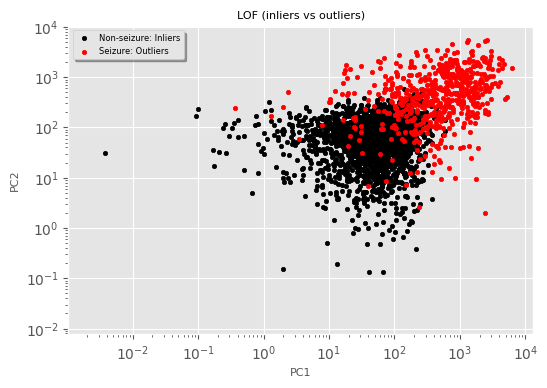

In [64]:
# 2-D scatter plot of LOF predicted outliers and scores
outlier_scatter_plot(X_reduced_df, 'lof_pred', 'LOF')

#### 2.4.2. Isolation Forest

In [ ]:
isf_best_params

Runtime: 269.717436 seconds


In [ ]:
optimized_isf = IsolationForest(n_estimators=isf_best_params['n_estimators'], max_samples=isf_best_params['max_samples'], 
                                contamination=outlier_frac, max_features=isf_best_params['max_features'], 
                                random_state=42, n_jobs=-1)

array([ 1, -1,  1, ...,  1,  1,  1])

In [65]:
optimized_isf = IsolationForest(n_estimators=400, max_samples=256, contamination=outlier_frac, max_features=0.8, 
                                random_state=42, n_jobs=-1)

In [66]:
optimized_isf.get_params()

{'bootstrap': False,
 'contamination': np.float64(0.2),
 'max_features': 0.8,
 'max_samples': 256,
 'n_estimators': 400,
 'n_jobs': -1,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [ ]:
# Get iForest labels and scores
# Start time 
start_time = datetime.now()
y_isf_pred, y_isf_scores, isf_n_features, isf_offset = model_predict(X, 'iForest', optimized_isf, isf_best_params['scaler'])
# End time 
end_time = datetime.now()
runtime_duration = end_time - start_time
print(f"Runtime: {runtime_duration.total_seconds()} seconds")

In [67]:
# Get iForest labels and scores
# Start time 
start_time = datetime.now()
y_isf_pred, y_isf_scores, isf_n_features, isf_offset = model_predict(X, 'iForest', optimized_isf, SplineTransformer())
# End time 
end_time = datetime.now()
runtime_duration = end_time - start_time
print(f"Runtime: {runtime_duration.total_seconds()} seconds")

Runtime: 200.033295 seconds


In [68]:
isf_n_features, isf_offset

(1246, np.float64(-0.34699907624769444))

In [69]:
y_isf_pred

array([ 1, -1,  1, ...,  1,  1,  1], shape=(11500,))

In [70]:
# Concatenate the labels and the scores
X_reduced_df['isf_score'] = y_isf_scores
X_reduced_df['isf_pred'] = y_isf_pred
X_reduced_df.head()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred
0,-91.36,184.32,0,No,-2.43,No,0.02,1
1,-313.08,474.98,1,Yes,-5.89,Yes,-0.21,-1
2,91.34,41.91,0,No,-1.28,No,0.03,1
3,-10.69,-48.28,0,No,-1.00,No,0.03,1
4,-36.03,-16.85,0,No,-1.30,No,0.04,1


In [71]:
X_reduced_df.tail()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred
11495,-2.73,52.10,0,No,-1.18,No,0.04,1
11496,-46.00,694.31,1,Yes,-3.53,Yes,-0.02,-1
11497,-52.37,21.52,0,No,-1.38,No,0.04,1
11498,-45.54,176.59,0,No,-1.64,No,0.03,1
11499,20.53,-48.80,0,No,-1.55,No,0.04,1


In [72]:
# Replace "-1" with "Yes" and "1" with "No"
X_reduced_df['isf_pred'] = X_reduced_df['isf_pred'].replace([-1, 1], ["Yes", "No"])
X_reduced_df.head()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred
0,-91.36,184.32,0,No,-2.43,No,0.02,No
1,-313.08,474.98,1,Yes,-5.89,Yes,-0.21,Yes
2,91.34,41.91,0,No,-1.28,No,0.03,No
3,-10.69,-48.28,0,No,-1.00,No,0.03,No
4,-36.03,-16.85,0,No,-1.30,No,0.04,No


In [73]:
X_reduced_df.tail()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred
11495,-2.73,52.10,0,No,-1.18,No,0.04,No
11496,-46.00,694.31,1,Yes,-3.53,Yes,-0.02,Yes
11497,-52.37,21.52,0,No,-1.38,No,0.04,No
11498,-45.54,176.59,0,No,-1.64,No,0.03,No
11499,20.53,-48.80,0,No,-1.55,No,0.04,No


In [74]:
#X_reduced_df[['isf_score', 'isf_pred']].sort_values(by='isf_score', ascending=True)

In [75]:
# The min and the max outlier scores
round(min(X_reduced_df['isf_score']), 2), round(max(X_reduced_df['isf_score']), 2)

(-0.34, 0.04)

In [76]:
# The min outlier score of those data points predicted as inliers
round(min(X_reduced_df[X_reduced_df['isf_pred']=='No']['isf_score']), 2)

0.0

In [77]:
# The max outlier score of those data points predicted as inliers
round(max(X_reduced_df[X_reduced_df['isf_pred']=='No']['isf_score']), 2)

0.04

In [78]:
# The min outlier score of those data points predicted as outliers
round(min(X_reduced_df[X_reduced_df['isf_pred']=='Yes']['isf_score']), 2)

-0.34

In [79]:
# The max outlier score of those data points predicted as outliers
round(max(X_reduced_df[X_reduced_df['isf_pred']=='Yes']['isf_score']), 2)

-0.0

In [80]:
# Number of data points predicted as inliers
X_reduced_df[X_reduced_df['isf_pred']=='No'].shape[0]

9200

In [81]:
# Number of data points predicted as outliers
X_reduced_df[X_reduced_df['isf_pred']=='Yes'].shape[0]

2300

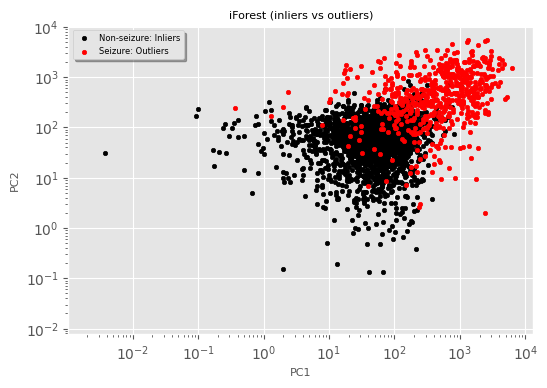

In [82]:
outlier_scatter_plot(X_reduced_df, 'isf_pred', 'iForest')

#### 2.4.3. One-Class SVM

In [ ]:
svm_best_params

Runtime: 146.672718 seconds


In [ ]:
optimized_svm = OneClassSVM(kernel=svm_best_params['kernel'], gamma=svm_best_params['gamma'], 
                            nu=outlier_frac)

array([ 1, -1,  1, ...,  1,  1,  1], dtype=int64)

In [83]:
optimized_svm = OneClassSVM(kernel='rbf', gamma=1.25, nu=outlier_frac)

In [84]:
optimized_svm.get_params()

{'cache_size': 200,
 'coef0': 0.0,
 'degree': 3,
 'gamma': 1.25,
 'kernel': 'rbf',
 'max_iter': -1,
 'nu': np.float64(0.2),
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [ ]:
# Get one-class SVM labels and scores
# Start time 
start_time = datetime.now()
y_svm_pred, y_svm_scores, svm_n_features, svm_offset = model_predict(X, 'One-Class SVM', optimized_svm, svm_best_params['scaler'])
# End time 
end_time = datetime.now()
runtime_duration = end_time - start_time
print(f"Runtime: {runtime_duration.total_seconds()} seconds")

In [85]:
# Get one-class SVM labels and scores
# Start time 
start_time = datetime.now()
y_svm_pred, y_svm_scores, svm_n_features, svm_offset = model_predict(X, 'One-Class SVM', optimized_svm, SplineTransformer())
# End time 
end_time = datetime.now()
runtime_duration = end_time - start_time
print(f"Runtime: {runtime_duration.total_seconds()} seconds")

Runtime: 115.646505 seconds


In [86]:
svm_n_features, svm_offset

(1246, array([2.8983886]))

In [87]:
y_svm_pred

array([ 1, -1,  1, ...,  1,  1,  1], shape=(11500,))

In [88]:
# Concatenate the labesl and the scores
X_reduced_df['svm_score'] = y_svm_scores
X_reduced_df['svm_pred'] = y_svm_pred
X_reduced_df.head()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred
0,-91.36,184.32,0,No,-2.43,No,0.02,No,1.40,1
1,-313.08,474.98,1,Yes,-5.89,Yes,-0.21,Yes,-1.90,-1
2,91.34,41.91,0,No,-1.28,No,0.03,No,8.16,1
3,-10.69,-48.28,0,No,-1.00,No,0.03,No,8.03,1
4,-36.03,-16.85,0,No,-1.30,No,0.04,No,9.66,1


In [89]:
X_reduced_df.tail()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred
11495,-2.73,52.10,0,No,-1.18,No,0.04,No,9.74,1
11496,-46.00,694.31,1,Yes,-3.53,Yes,-0.02,Yes,-1.37,-1
11497,-52.37,21.52,0,No,-1.38,No,0.04,No,8.32,1
11498,-45.54,176.59,0,No,-1.64,No,0.03,No,5.41,1
11499,20.53,-48.80,0,No,-1.55,No,0.04,No,8.25,1


In [90]:
# Replace "-1" with "Yes" and "1" with "No"
X_reduced_df['svm_pred'] = X_reduced_df['svm_pred'].replace([-1, 1], ["Yes", "No"])
X_reduced_df.head()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred
0,-91.36,184.32,0,No,-2.43,No,0.02,No,1.40,No
1,-313.08,474.98,1,Yes,-5.89,Yes,-0.21,Yes,-1.90,Yes
2,91.34,41.91,0,No,-1.28,No,0.03,No,8.16,No
3,-10.69,-48.28,0,No,-1.00,No,0.03,No,8.03,No
4,-36.03,-16.85,0,No,-1.30,No,0.04,No,9.66,No


In [91]:
X_reduced_df.tail()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred
11495,-2.73,52.10,0,No,-1.18,No,0.04,No,9.74,No
11496,-46.00,694.31,1,Yes,-3.53,Yes,-0.02,Yes,-1.37,Yes
11497,-52.37,21.52,0,No,-1.38,No,0.04,No,8.32,No
11498,-45.54,176.59,0,No,-1.64,No,0.03,No,5.41,No
11499,20.53,-48.80,0,No,-1.55,No,0.04,No,8.25,No


In [92]:
#X_reduced_df[['svm_score', 'svm_pred']].sort_values(by='svm_score', ascending=True)

In [93]:
# The min and the max outlier scores
round(min(X_reduced_df['svm_score']), 2), round(max(X_reduced_df['svm_score']), 2)

(-1.9, 12.22)

In [94]:
# The min outlier score of those data points predicted as inliers
round(min(X_reduced_df[X_reduced_df['svm_pred']=='No']['svm_score']), 2)

0.0

In [95]:
# The max outlier score of those data points predicted as inliers
round(max(X_reduced_df[X_reduced_df['svm_pred']=='No']['svm_score']), 2)

12.22

In [96]:
# The min outlier score of those data points predicted as outliers
round(min(X_reduced_df[X_reduced_df['svm_pred']=='Yes']['svm_score']), 2)

-1.9

In [97]:
# The max outlier score of those data points predicted as outliers
round(max(X_reduced_df[X_reduced_df['svm_pred']=='Yes']['svm_score']), 2)

-0.0

In [98]:
# Number of data points predicted as inliers
X_reduced_df[X_reduced_df['svm_pred']=='No'].shape[0]

9187

In [99]:
# Number of data points predicted as outliers
X_reduced_df[X_reduced_df['svm_pred']=='Yes'].shape[0]

2313

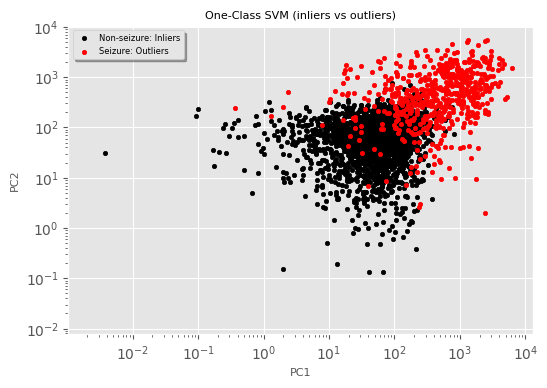

In [100]:
outlier_scatter_plot(X_reduced_df, 'svm_pred', 'One-Class SVM')

#### 2.4.4. MCD

In [ ]:
mcd_best_params

Runtime: 978.161791 seconds


In [ ]:
optimized_mcd = EllipticEnvelope(support_fraction=mcd_best_params['support_fraction'], contamination=outlier_frac, random_state=0)

array([ 1, -1,  1, ...,  1,  1,  1])

In [101]:
optimized_mcd = EllipticEnvelope(support_fraction=0.875, contamination=outlier_frac, random_state=0)

In [102]:
optimized_mcd.get_params()

{'assume_centered': False,
 'contamination': np.float64(0.2),
 'random_state': 0,
 'store_precision': True,
 'support_fraction': 0.875}

In [ ]:
# Get MCD labels and scores
# Start time 
start_time = datetime.now()
y_mcd_pred, y_mcd_scores, mcd_n_features, mcd_offset = model_predict(X, 'MCD', optimized_mcd, mcd_best_params['scaler'])
# End time 
end_time = datetime.now()
runtime_duration = end_time - start_time
print(f"Runtime: {runtime_duration.total_seconds()} seconds")

In [103]:
mcd_pipeline = make_pipeline(SplineTransformer(), optimized_mcd)

In [104]:
mcd_pipeline.fit(X)

Pipeline(steps=[('splinetransformer', SplineTransformer()),
                ('ellipticenvelope',
                 EllipticEnvelope(contamination=np.float64(0.2), random_state=0,
                                  support_fraction=0.875))])

In [105]:
# Get outlier labels and scores
#n_features = pipeline_model[-1].n_features_in_
#offset = pipeline_model[-1].offset_
y_mcd_pred = mcd_pipeline.predict(X)
y_mcd_scores = mcd_pipeline.decision_function(X)

In [ ]:
# Get MCD labels and scores
# Start time 
start_time = datetime.now()
y_mcd_pred, y_mcd_scores, mcd_n_features, mcd_offset = model_predict(X, 'MCD', optimized_mcd, SplineTransformer())
# End time 
end_time = datetime.now()
runtime_duration = end_time - start_time
print(f"Runtime: {runtime_duration.total_seconds()} seconds")

In [ ]:
mcd_n_features, mcd_offset

In [106]:
y_mcd_pred

array([ 1, -1,  1, ...,  1,  1,  1], shape=(11500,))

In [107]:
# Concatenate the labels and the scores
X_reduced_df['mcd_score'] = y_mcd_scores
X_reduced_df['mcd_pred'] = y_mcd_pred
X_reduced_df.head()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred,mcd_score,mcd_pred
0,-91.36,184.32,0,No,-2.43,No,0.02,No,1.40,No,1111870.21,1
1,-313.08,474.98,1,Yes,-5.89,Yes,-0.21,Yes,-1.90,Yes,-223405506445.25,-1
2,91.34,41.91,0,No,-1.28,No,0.03,No,8.16,No,1167359.52,1
3,-10.69,-48.28,0,No,-1.00,No,0.03,No,8.03,No,1167967.03,1
4,-36.03,-16.85,0,No,-1.30,No,0.04,No,9.66,No,1167409.65,1


In [108]:
X_reduced_df.tail()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred,mcd_score,mcd_pred
11495,-2.73,52.10,0,No,-1.18,No,0.04,No,9.74,No,1168122.92,1
11496,-46.00,694.31,1,Yes,-3.53,Yes,-0.02,Yes,-1.37,Yes,-31924707.69,-1
11497,-52.37,21.52,0,No,-1.38,No,0.04,No,8.32,No,1164440.54,1
11498,-45.54,176.59,0,No,-1.64,No,0.03,No,5.41,No,1165361.44,1
11499,20.53,-48.80,0,No,-1.55,No,0.04,No,8.25,No,1167518.34,1


In [109]:
# Replace "-1" with "Yes" and "1" with "No"
X_reduced_df['mcd_pred'] = X_reduced_df['mcd_pred'].replace([-1, 1], ["Yes", "No"])
X_reduced_df.head()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred,mcd_score,mcd_pred
0,-91.36,184.32,0,No,-2.43,No,0.02,No,1.40,No,1111870.21,No
1,-313.08,474.98,1,Yes,-5.89,Yes,-0.21,Yes,-1.90,Yes,-223405506445.25,Yes
2,91.34,41.91,0,No,-1.28,No,0.03,No,8.16,No,1167359.52,No
3,-10.69,-48.28,0,No,-1.00,No,0.03,No,8.03,No,1167967.03,No
4,-36.03,-16.85,0,No,-1.30,No,0.04,No,9.66,No,1167409.65,No


In [110]:
X_reduced_df.tail()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred,mcd_score,mcd_pred
11495,-2.73,52.10,0,No,-1.18,No,0.04,No,9.74,No,1168122.92,No
11496,-46.00,694.31,1,Yes,-3.53,Yes,-0.02,Yes,-1.37,Yes,-31924707.69,Yes
11497,-52.37,21.52,0,No,-1.38,No,0.04,No,8.32,No,1164440.54,No
11498,-45.54,176.59,0,No,-1.64,No,0.03,No,5.41,No,1165361.44,No
11499,20.53,-48.80,0,No,-1.55,No,0.04,No,8.25,No,1167518.34,No


In [111]:
#X_reduced_df[['mcd_score', 'mcd_pred']].sort_values(by='mcd_score', ascending=True)

In [112]:
# The min and the max outlier scores
round(min(X_reduced_df['mcd_score']), 2), round(max(X_reduced_df['mcd_score']), 2)

(-22604523533351.79, 1168230.19)

In [113]:
# The min outlier score of those data points predicted as inliers
round(min(X_reduced_df[X_reduced_df['mcd_pred']=='No']['mcd_score']), 2)

455.24

In [114]:
# The max outlier score of those data points predicted as inliers
round(max(X_reduced_df[X_reduced_df['mcd_pred']=='No']['mcd_score']), 2)

1168230.19

In [115]:
# The min outlier score of those data points predicted as outliers
round(min(X_reduced_df[X_reduced_df['mcd_pred']=='Yes']['mcd_score']), 2)

-22604523533351.79

In [116]:
# The max outlier score of those data points predicted as outliers
round(max(X_reduced_df[X_reduced_df['mcd_pred']=='Yes']['mcd_score']), 2)

-1820.95

In [117]:
# Number of data points predicted as inliers
X_reduced_df[X_reduced_df['mcd_pred']=='No'].shape[0]

9200

In [118]:
# Number of data points predicted as outliers
X_reduced_df[X_reduced_df['mcd_pred']=='Yes'].shape[0]

2300

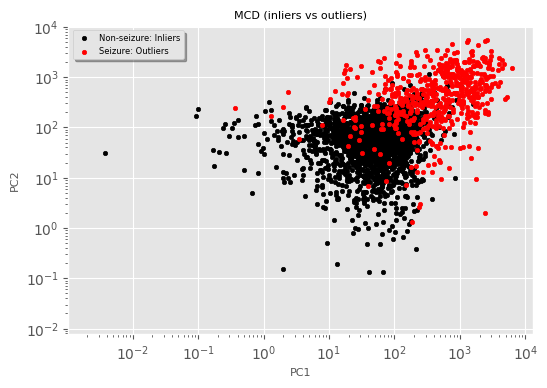

In [119]:
outlier_scatter_plot(X_reduced_df, 'mcd_pred', 'MCD')

#### 2.5. ROC Curves to Compare Performance

In [120]:
# Define lists for outlier models - names and scores
model_names = ['LOF', 'iForest', 'One-Class SVM', 'MCD']
model_score_list = [y_lof_scores, y_isf_scores, y_svm_scores, y_mcd_scores]

In [ ]:
#fig.clf()
#ax.clear()

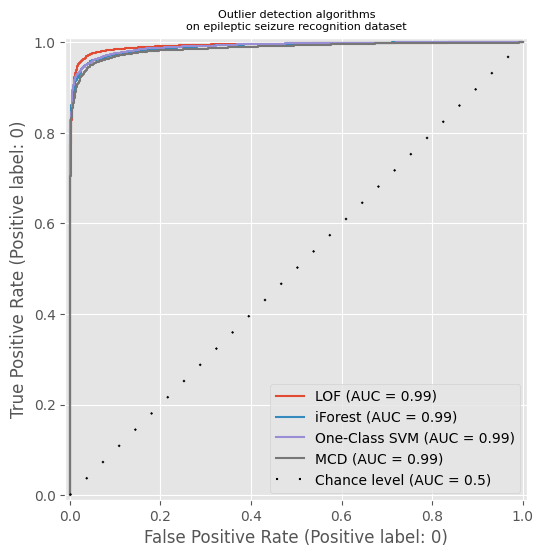

In [159]:
fig, ax = plt.subplots(figsize=(8, 6))
for idx, (model_name, model_scores) in enumerate(zip(model_names, model_score_list)):
    RocCurveDisplay.from_predictions(
    y_true,
    model_scores,
    pos_label=0,
    ax=ax,
    name=model_name,
    plot_chance_level=(idx == len(model_score_list) - 1),
    chance_level_kw={"linestyle": (0, (1, 10))}
    # linestyle=linestyle[idx]
    )
_ = ax.set_title(f"Outlier detection algorithms\non epileptic seizure recognition dataset", fontsize=8)
fig.show()

### 3. Evaluation Metrics from Confusion Matrix

In [123]:
# Define a function to return accuracy scores and confusion matrix
def cm_accuracy_score(y_true, y_pred):
    y_pred = np.where(y_pred == -1, 1, 0)
    accuracy_score_ = accuracy_score(y_true, y_pred)
    balanced_accuracy_score_ = balanced_accuracy_score(y_true, y_pred)
    # Compute the confusion matrix
    cm_obj = confusion_matrix(y_true, y_pred)
    return accuracy_score_, balanced_accuracy_score_, cm_obj

In [124]:
# Function to calculate evaluation metrics derived from confusion matrix
def metrics_from_confusion_matrix(confusion_matrix_obj):
    # Get the values from confusion matrix
    TP = confusion_matrix_obj[0, 0]
    FP = confusion_matrix_obj[1, 0]
    FN = confusion_matrix_obj[0, 1]
    TN = confusion_matrix_obj[1, 1]

    # Compute TPR, TNR, PPV, NPV
    TPR = TP / (TP + FN)
    TNR = TN / (TN + FP)
    PPV = TP / (TP + FP)
    NPV = TN / (TN + FN)

    return print(f"TP: {TP}, FP: {FP}, FN: {FN}, TN: {TN}\nTPR: {round(TPR, 4)}, TNR: {round(TNR, 4)}, PPV: {round(PPV, 4)}, NPV: {round(NPV, 4)}")

#### 3.1. Local Outlier Factor Evaluation

In [125]:
# Get the accuracy scores and confusion matrix object
lof_accuracy_score, lof_balanced_accuracy_score, lof_cm_obj = cm_accuracy_score(y_true, y_lof_pred)

In [126]:
# Print the percent prediction accuracy
print(str(round(lof_accuracy_score*100, 4)) + ' %')
print(str(round(lof_balanced_accuracy_score*100, 4)) + ' %')

96.9739 %
95.2717 %


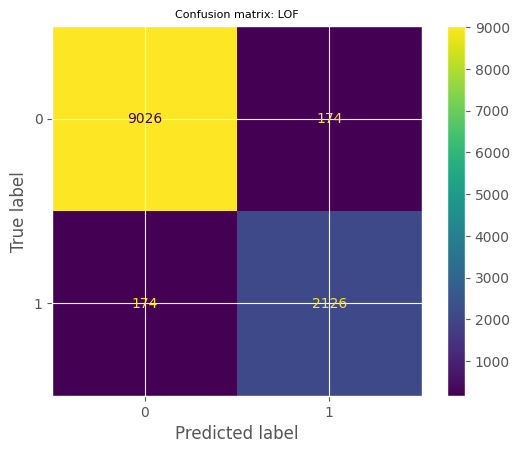

In [127]:
# Display confusion matrix
lof_disp = ConfusionMatrixDisplay(lof_cm_obj)
lof_disp.plot()
plt.title("Confusion matrix: LOF", fontsize=8)
plt.show()

In [128]:
# Get the calculated metrics
metrics_from_confusion_matrix(lof_cm_obj)

TP: 9026, FP: 174, FN: 174, TN: 2126
TPR: 0.9811, TNR: 0.9243, PPV: 0.9811, NPV: 0.9243


#### 3.2. Isolation Forest Evaluation

In [129]:
# Get the accuracy scores and confusion matrix object
isf_accuracy_score, isf_balanced_accuracy_score, isf_cm_obj = cm_accuracy_score(y_true, y_isf_pred)

In [130]:
# Print the percent prediction accuracy
print(str(round(isf_accuracy_score*100, 4)) + ' %')
print(str(round(isf_balanced_accuracy_score*100, 4)) + ' %')

95.8261 %
93.4783 %


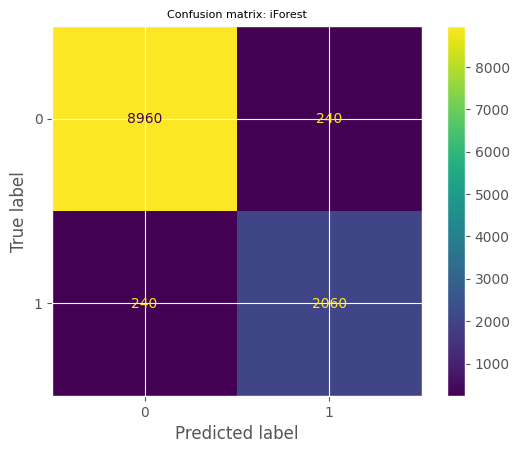

In [131]:
# Display confusion matrix
isf_disp = ConfusionMatrixDisplay(isf_cm_obj)
isf_disp.plot()
plt.title("Confusion matrix: iForest", fontsize=8)
plt.show()

In [132]:
# Get the calculated metrics
metrics_from_confusion_matrix(isf_cm_obj)

TP: 8960, FP: 240, FN: 240, TN: 2060
TPR: 0.9739, TNR: 0.8957, PPV: 0.9739, NPV: 0.8957


#### 3.3. One-Class SVM Evaluation

In [133]:
# Get the accuracy scores and confusion matrix object
svm_accuracy_score, svm_balanced_accuracy_score, svm_cm_obj = cm_accuracy_score(y_true, y_svm_pred)

In [134]:
# Print the percent prediction accuracy
print(str(round(svm_accuracy_score*100, 4)) + ' %')
print(str(round(svm_balanced_accuracy_score*100, 4)) + ' %')

96.0957 %
94.0054 %


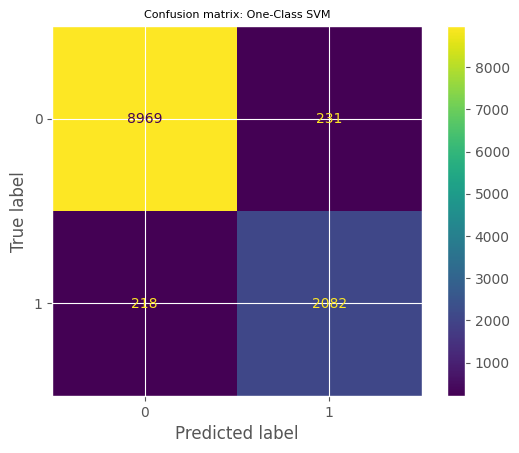

In [135]:
# Display confusion matrix
svm_disp = ConfusionMatrixDisplay(svm_cm_obj)
svm_disp.plot()
plt.title("Confusion matrix: One-Class SVM", fontsize=8)
plt.show()

In [136]:
# Get the calculated metrics
metrics_from_confusion_matrix(svm_cm_obj)

TP: 8969, FP: 218, FN: 231, TN: 2082
TPR: 0.9749, TNR: 0.9052, PPV: 0.9763, NPV: 0.9001


#### 3.4. MCD Evaluation

In [137]:
# Get the accuracy scores and confusion matrix object
mcd_accuracy_score, mcd_balanced_accuracy_score, mcd_cm_obj = cm_accuracy_score(y_true, y_mcd_pred)

In [138]:
# Print the percent prediction accuracy
print(str(round(mcd_accuracy_score*100, 2)) + ' %')
print(str(round(mcd_balanced_accuracy_score*100, 2)) + ' %')

95.51 %
92.99 %


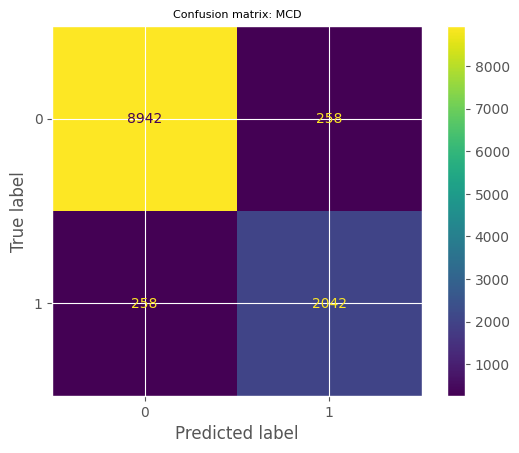

In [139]:
# Display confusion matrix
mcd_disp = ConfusionMatrixDisplay(mcd_cm_obj)
mcd_disp.plot()
plt.title("Confusion matrix: MCD", fontsize=8)
plt.show()

In [140]:
# Get the calculated metrics
metrics_from_confusion_matrix(mcd_cm_obj)

TP: 8942, FP: 258, FN: 258, TN: 2042
TPR: 0.972, TNR: 0.8878, PPV: 0.972, NPV: 0.8878


### 4. DBSCAN

#### 4.1. Determine Epsilon and MinPts

In [45]:
# Function to plot k-distance graph
def k_distance_plot(X_scaled, scaler_name, n_neighbors):
    neighbors = NearestNeighbors(n_neighbors=n_neighbors)
    neighbors_fit = neighbors.fit(X_scaled)
    dists, indices = neighbors_fit.kneighbors(X_scaled)
    dists = np.sort(dists, axis=0)
    # print(dists[:, 1])
    dists = dists[:, 1]
    plt.plot(dists, label=scaler_name)

In [46]:
# Define scaling methods
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
    'SplineTransformer': SplineTransformer(),
    'Normalizer': Normalizer()
    #'None': None
    
}

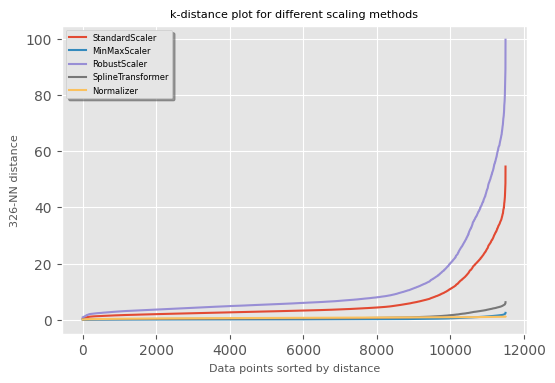

In [47]:
# k-distance plots
plt.figure(figsize=(6, 4))
for scaler_name, scaler in scalers.items():
    X_scaled = scaler.fit_transform(X)
    k_distance_plot(X_scaled, scaler_name, 326)   
plt.xlabel('Data points sorted by distance', fontsize=8)
plt.ylabel('326-NN distance', fontsize=8)
plt.title('k-distance plot for different scaling methods', fontsize=8)
plt.legend(shadow=True, fontsize=6)
plt.show()

#### 4.2. Hyperparameter Optimization

In [59]:
# Compose dbscan parameter values
eps_values = [i /10 for i in range(50, 225, 25)] # 0.8 to 3.2 inclusive
#[3, 5, 10, 15, 20]
min_samples_values = [*range(326, 370, 10)] # 13 to 26 inclusive

In [60]:
eps_values

[5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0]

In [61]:
min_samples_values

[326, 336, 346, 356, 366]

In [ ]:
# dbscan_params = { 'scaler': [ MinMaxScaler(), SplineTransformer(), StandardScaler(), RobustScaler()], 'eps': eps_values, 'min_samples': min_samples_values }
# # Define parameter grid
# dbscan_param_grid = ParameterGrid(dbscan_params)

In [62]:
dbscan_params = { 'scaler': preprocessor_list, 'eps': eps_values, 'min_samples': min_samples_values }
# Define parameter grid
dbscan_param_grid = ParameterGrid(dbscan_params)

In [63]:
len(list(dbscan_param_grid))

105

In [64]:
list(dbscan_param_grid)[:10]

[{'eps': 5.0, 'min_samples': 326, 'scaler': StandardScaler()},
 {'eps': 5.0, 'min_samples': 326, 'scaler': RobustScaler()},
 {'eps': 5.0, 'min_samples': 326, 'scaler': SplineTransformer()},
 {'eps': 5.0, 'min_samples': 336, 'scaler': StandardScaler()},
 {'eps': 5.0, 'min_samples': 336, 'scaler': RobustScaler()},
 {'eps': 5.0, 'min_samples': 336, 'scaler': SplineTransformer()},
 {'eps': 5.0, 'min_samples': 346, 'scaler': StandardScaler()},
 {'eps': 5.0, 'min_samples': 346, 'scaler': RobustScaler()},
 {'eps': 5.0, 'min_samples': 346, 'scaler': SplineTransformer()},
 {'eps': 5.0, 'min_samples': 356, 'scaler': StandardScaler()}]

In [65]:
# Function for tuning DBSCAN hyperparameters
def dbscan_params_search(X, y_pred, param_grid, n_components):
    dbscan_best_score = -1
    dbscan_best_params = {}
    dbscan_params_metric_scores = []
    #score_list = []
    #counter = 1440
    if n_components is None:
        for params in param_grid:
            eps = params['eps']
            min_samples = params['min_samples']
            scaler = params['scaler']
            #X_scaled = scaler.fit_transform(X)
            dbscan_obj = DBSCAN(eps=eps, min_samples=min_samples)
            model = make_pipeline(scaler, dbscan_obj)
            model.fit(X)
            # dbscan = dbscan_obj.fit(X_scaled)           
            dbscan_labels = model[-1].labels_ 
            
            # Make sure the dbscan produces at least 2 unique labels and noise (outliers)
            if len(set(dbscan_labels)) > 1 and list(dbscan_labels).count(-1) > 0:                
                # Convert dbscan labels to binary labels
                y_pred = np.where(dbscan_labels == -1, 1, 0)
                # Use binary classifier metric since dbscan is used as an outlier detection technique here
                # Balance accuracy is easy to interpret, value between 0 and 1
                score = balanced_accuracy_score(y_true, y_pred)               
                dbscan_params_metric_scores.append({**params, 'balanced_accuracy_score': score})
                if score > dbscan_best_score:
                    dbscan_best_score = score
                    dbscan_best_params = params
                    # Points labeled as -1 by DBSCAN are considered noise (outliers)
                    dbscan_best_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
                    dbscan_best_outliers = list(dbscan_labels).count(-1)
            
    else:
        for params in param_grid:
            eps=params['eps']
            min_samples = params['min_samples']
            scaler = params['scaler']
            # X_scaled = scaler.fit_transform(X)
            # X_pca = PCA(n_components=n_components).fit_transform(X_scaled)
            PCA_obj = PCA(n_components=n_components)
            dbscan_obj = DBSCAN(eps=eps, min_samples=min_samples)
            model = make_pipeline(scaler, PCA_obj, dbscan_obj)
            model.fit(X)
            dbscan_labels = model[-1].labels_
            # dbscan = dbscan_obj.fit(X_pca)
            # dbscan_labels = dbscan.labels_
            # Make sure the dbscan produces at least 2 unique labels and noise (outliers)
            if len(set(dbscan_labels)) > 1 and list(dbscan_labels).count(-1) > 0:               
                # Convert dbscan labels to binary labels
                y_pred = np.where(dbscan_labels == -1, 1, 0)
                # Use binary classifier metric since dbscan is used as an outlier detection technique
                # Balance accuracy is easy to interpret, value between 0 and 1
                score = balanced_accuracy_score(y_true, y_pred)
                dbscan_params_metric_scores.append({**params, 'balanced_accuracy_score': score})              
                if score > dbscan_best_score:
                    dbscan_best_score = score
                    dbscan_best_params = params
                    # Points labeled as -1 by DBSCAN are considered noise (outliers)
                    dbscan_best_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
                    dbscan_best_outliers = list(dbscan_labels).count(-1)

    return dbscan_best_score, dbscan_best_params, dbscan_best_clusters, dbscan_best_outliers, dbscan_params_metric_scores



In [66]:
# Start time 
#start_time = datetime.now()
dbscan_best_score, dbscan_best_params, dbscan_best_clusters, dbscan_best_outliers, dbscan_params_metric_scores = dbscan_params_search(X, y_true, dbscan_param_grid, None)
# End time 
#end_time = datetime.now()
#runtime_duration = end_time - start_time
#print(f"Runtime: {runtime_duration.total_seconds()} seconds")

In [67]:
dbscan_best_score, dbscan_best_params

(np.float64(0.9610869565217391),
 {'eps': 12.5, 'min_samples': 326, 'scaler': RobustScaler()})

In [68]:
dbscan_best_clusters, dbscan_best_outliers

(1, 2491)

In [69]:
dbscan_params_metric_scores.sort(key=lambda x: x['balanced_accuracy_score'], reverse=True)

In [70]:
dbscan_params_metric_scores[:10]

[{'eps': 12.5,
  'min_samples': 326,
  'scaler': RobustScaler(),
  'balanced_accuracy_score': np.float64(0.9610869565217391)},
 {'eps': 12.5,
  'min_samples': 336,
  'scaler': RobustScaler(),
  'balanced_accuracy_score': np.float64(0.9610869565217391)},
 {'eps': 12.5,
  'min_samples': 346,
  'scaler': RobustScaler(),
  'balanced_accuracy_score': np.float64(0.9610869565217391)},
 {'eps': 12.5,
  'min_samples': 356,
  'scaler': RobustScaler(),
  'balanced_accuracy_score': np.float64(0.9610869565217391)},
 {'eps': 12.5,
  'min_samples': 366,
  'scaler': RobustScaler(),
  'balanced_accuracy_score': np.float64(0.9610326086956522)},
 {'eps': 10.0,
  'min_samples': 346,
  'scaler': RobustScaler(),
  'balanced_accuracy_score': np.float64(0.9571739130434782)},
 {'eps': 10.0,
  'min_samples': 356,
  'scaler': RobustScaler(),
  'balanced_accuracy_score': np.float64(0.9570108695652174)},
 {'eps': 10.0,
  'min_samples': 366,
  'scaler': RobustScaler(),
  'balanced_accuracy_score': np.float64(0.9570

In [71]:
len(dbscan_params_metric_scores)

75

In [72]:
# Get the best hyperparameter values for SplineTransformer
dbscan_spline_params_metric_scores = [s for s in dbscan_params_metric_scores if str(s['scaler']) == 'SplineTransformer()']

In [73]:
dbscan_spline_params_metric_scores[:5]

[{'eps': 5.0,
  'min_samples': 326,
  'scaler': SplineTransformer(),
  'balanced_accuracy_score': np.float64(0.5278260869565218)},
 {'eps': 5.0,
  'min_samples': 336,
  'scaler': SplineTransformer(),
  'balanced_accuracy_score': np.float64(0.5278260869565218)},
 {'eps': 5.0,
  'min_samples': 346,
  'scaler': SplineTransformer(),
  'balanced_accuracy_score': np.float64(0.5278260869565218)},
 {'eps': 5.0,
  'min_samples': 356,
  'scaler': SplineTransformer(),
  'balanced_accuracy_score': np.float64(0.5278260869565218)},
 {'eps': 5.0,
  'min_samples': 366,
  'scaler': SplineTransformer(),
  'balanced_accuracy_score': np.float64(0.5278260869565218)}]

In [74]:
len(dbscan_spline_params_metric_scores)

5

In [75]:
# Get the best hyperparameter values for StandardScaler
dbscan_standard_params_metric_scores = [s for s in dbscan_params_metric_scores if str(s['scaler']) == 'StandardScaler()']

In [76]:
dbscan_standard_params_metric_scores[:5]

[{'eps': 7.5,
  'min_samples': 326,
  'scaler': StandardScaler(),
  'balanced_accuracy_score': np.float64(0.9482608695652175)},
 {'eps': 7.5,
  'min_samples': 336,
  'scaler': StandardScaler(),
  'balanced_accuracy_score': np.float64(0.9482608695652175)},
 {'eps': 7.5,
  'min_samples': 346,
  'scaler': StandardScaler(),
  'balanced_accuracy_score': np.float64(0.9482608695652175)},
 {'eps': 7.5,
  'min_samples': 356,
  'scaler': StandardScaler(),
  'balanced_accuracy_score': np.float64(0.9482608695652175)},
 {'eps': 7.5,
  'min_samples': 366,
  'scaler': StandardScaler(),
  'balanced_accuracy_score': np.float64(0.9482608695652175)}]

In [77]:
len(dbscan_standard_params_metric_scores)

35

In [78]:
# Get the best hyperparameter values for RobustScaler
dbscan_robust_params_metric_scores = [s for s in dbscan_params_metric_scores if str(s['scaler']) == 'RobustScaler()']

In [79]:
dbscan_robust_params_metric_scores[:5]

[{'eps': 12.5,
  'min_samples': 326,
  'scaler': RobustScaler(),
  'balanced_accuracy_score': np.float64(0.9610869565217391)},
 {'eps': 12.5,
  'min_samples': 336,
  'scaler': RobustScaler(),
  'balanced_accuracy_score': np.float64(0.9610869565217391)},
 {'eps': 12.5,
  'min_samples': 346,
  'scaler': RobustScaler(),
  'balanced_accuracy_score': np.float64(0.9610869565217391)},
 {'eps': 12.5,
  'min_samples': 356,
  'scaler': RobustScaler(),
  'balanced_accuracy_score': np.float64(0.9610869565217391)},
 {'eps': 12.5,
  'min_samples': 366,
  'scaler': RobustScaler(),
  'balanced_accuracy_score': np.float64(0.9610326086956522)}]

In [80]:
len(dbscan_robust_params_metric_scores)

35

In [89]:
# Get the best hyperparameter values for MinMaxScaler
dbscan_minmax_params_metric_scores = [s for s in dbscan_params_metric_scores if str(s['scaler']) == 'MinMaxScaler()']

In [90]:
dbscan_minmax_params_metric_scores[:5]

[]

In [91]:
len(dbscan_minmax_params_metric_scores)

0

In [92]:
# Get the best hyperparameter values for Normalizer
dbscan_normalizer_params_metric_scores = [s for s in dbscan_params_metric_scores if str(s['scaler']) == 'Normalizer()']

In [93]:
dbscan_normalizer_params_metric_scores[:5]

[]

In [94]:
len(dbscan_normalizer_params_metric_scores)

0

In [95]:
# Get the best hyperparameter values for None
dbscan_none_params_metric_scores = [s for s in dbscan_params_metric_scores if str(s['scaler']) == 'None']

In [96]:
dbscan_none_params_metric_scores[:5]

[]

In [97]:
len(dbscan_none_params_metric_scores)

0

#### 4.3 Prediction Labels

In [82]:
dbscan_best_params

{'eps': 12.5, 'min_samples': 326, 'scaler': RobustScaler()}

In [ ]:
# Use the optimized dbscan params to define dbscan object
optimized_dbscan = DBSCAN(eps=dbscan_best_params['eps'], min_samples=dbscan_best_params['min_samples'])

In [144]:
# Use the optimized dbscan params to define dbscan object
optimized_dbscan = DBSCAN(eps=12.5, min_samples=326)

In [86]:
# Start time 
#start_time = datetime.now()
y_dbscan_pred, _, _, _ = model_predict(X, 'dbscan', optimized_dbscan, dbscan_best_params['scaler'])
# End time 
#end_time = datetime.now()
#runtime_duration = end_time - start_time
#print(f"Runtime: {runtime_duration.total_seconds()} seconds")

In [145]:
# Start time 
#start_time = datetime.now()
y_dbscan_pred, _, _, _ = model_predict(X, 'dbscan', optimized_dbscan, RobustScaler())
# End time 
#end_time = datetime.now()
#runtime_duration = end_time - start_time
#print(f"Runtime: {runtime_duration.total_seconds()} seconds")

In [146]:
y_dbscan_pred

array([ 0, -1,  0, ...,  0,  0,  0], shape=(11500,))

In [147]:
# How many points labeled as outliers by dbscan
list(y_dbscan_pred).count(-1)

2491

In [148]:
# Concatenate the labels
X_reduced_df['dbscan_pred'] = y_dbscan_pred
X_reduced_df.head()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred,mcd_score,mcd_pred,dbscan_pred
0,-91.36,184.32,0,No,-2.43,No,0.02,No,1.40,No,1111870.21,No,0
1,-313.08,474.98,1,Yes,-5.89,Yes,-0.21,Yes,-1.90,Yes,-223405506445.25,Yes,-1
2,91.34,41.91,0,No,-1.28,No,0.03,No,8.16,No,1167359.52,No,0
3,-10.69,-48.28,0,No,-1.00,No,0.03,No,8.03,No,1167967.03,No,0
4,-36.03,-16.85,0,No,-1.30,No,0.04,No,9.66,No,1167409.65,No,0


In [149]:
X_reduced_df.tail()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred,mcd_score,mcd_pred,dbscan_pred
11495,-2.73,52.10,0,No,-1.18,No,0.04,No,9.74,No,1168122.92,No,0
11496,-46.00,694.31,1,Yes,-3.53,Yes,-0.02,Yes,-1.37,Yes,-31924707.69,Yes,-1
11497,-52.37,21.52,0,No,-1.38,No,0.04,No,8.32,No,1164440.54,No,0
11498,-45.54,176.59,0,No,-1.64,No,0.03,No,5.41,No,1165361.44,No,0
11499,20.53,-48.80,0,No,-1.55,No,0.04,No,8.25,No,1167518.34,No,0


In [150]:
# Replace "-1" with "Yes" and "0" with "No" for dbscan
X_reduced_df['dbscan_pred'] = X_reduced_df['dbscan_pred'].replace([-1, 0], ["Yes", "No"])
X_reduced_df.head()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred,mcd_score,mcd_pred,dbscan_pred
0,-91.36,184.32,0,No,-2.43,No,0.02,No,1.40,No,1111870.21,No,No
1,-313.08,474.98,1,Yes,-5.89,Yes,-0.21,Yes,-1.90,Yes,-223405506445.25,Yes,Yes
2,91.34,41.91,0,No,-1.28,No,0.03,No,8.16,No,1167359.52,No,No
3,-10.69,-48.28,0,No,-1.00,No,0.03,No,8.03,No,1167967.03,No,No
4,-36.03,-16.85,0,No,-1.30,No,0.04,No,9.66,No,1167409.65,No,No


In [151]:
X_reduced_df.tail()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred,mcd_score,mcd_pred,dbscan_pred
11495,-2.73,52.10,0,No,-1.18,No,0.04,No,9.74,No,1168122.92,No,No
11496,-46.00,694.31,1,Yes,-3.53,Yes,-0.02,Yes,-1.37,Yes,-31924707.69,Yes,Yes
11497,-52.37,21.52,0,No,-1.38,No,0.04,No,8.32,No,1164440.54,No,No
11498,-45.54,176.59,0,No,-1.64,No,0.03,No,5.41,No,1165361.44,No,No
11499,20.53,-48.80,0,No,-1.55,No,0.04,No,8.25,No,1167518.34,No,No


In [152]:
# Number of data points predicted as inliers
X_reduced_df[X_reduced_df['dbscan_pred']=='No'].shape[0]

9009

In [153]:
# Number of data points predicted as outliers
X_reduced_df[X_reduced_df['dbscan_pred']=='Yes'].shape[0]

2491

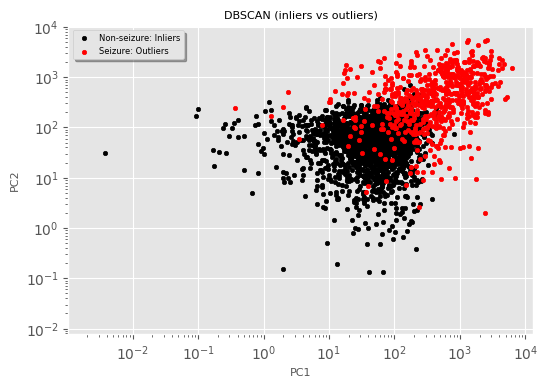

In [154]:
plt.figure(figsize=(6, 4))
plt.scatter(X_reduced_df['PC1'][X_reduced_df['dbscan_pred']=="No"], 
            X_reduced_df['PC2'][X_reduced_df['dbscan_pred']=="No"], 
            c='black',
            s=5*2,
            label='Non-seizure: Inliers')
    
plt.scatter(X_reduced_df['PC1'][X_reduced_df['dbscan_pred']=="Yes"], 
            X_reduced_df['PC2'][X_reduced_df['dbscan_pred']=="Yes"], 
            c='red',
            s=5*2,
            label='Seizure: Outliers')
plt.title("DBSCAN (inliers vs outliers)", fontsize=8)
plt.legend(shadow=True, fontsize=6)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("PC1", fontsize=8)
plt.ylabel("PC2", fontsize=8)
plt.show()

#### 4.4. Evaluation Metrics from Confusion Matrix

In [155]:
dbscan_accuracy_score, dbscan_balanced_accuracy_score, dbscan_cm_obj = cm_accuracy_score(y_true, y_dbscan_pred)

In [156]:
# Print the percent prediction accuracy
print(str(round(dbscan_accuracy_score*100, 4)) + ' %')
print(str(round(dbscan_balanced_accuracy_score*100, 4)) + ' %')

96.513 %
96.1087 %


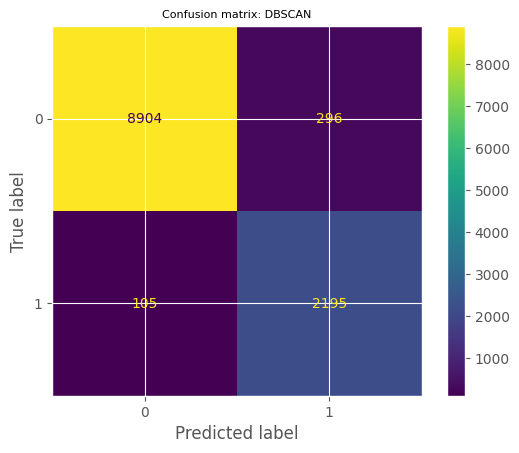

In [157]:
# Display confusion matrix
dbscan_disp = ConfusionMatrixDisplay(dbscan_cm_obj)
dbscan_disp.plot()
plt.title("Confusion matrix: DBSCAN", fontsize=8)
plt.show()

In [158]:
# Get the metrics calculated from confusion matrix
metrics_from_confusion_matrix(dbscan_cm_obj)

TP: 8904, FP: 105, FN: 296, TN: 2195
TPR: 0.9678, TNR: 0.9543, PPV: 0.9883, NPV: 0.8812
